<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=274857574" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is undervalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import multiprocessing as mp
import json
from sklearn import linear_model, preprocessing
pd.set_option('display.max_rows', 200)
# Workaround for a pandas bug, as described here:
# https://stackoverflow.com/questions/30519487/pandas-error-invalid-value-encountered
pd.set_option('display.float_format', lambda x:'%f'%x)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


In [3]:
if __name__ == '__main__':
    mp.set_start_method('fork')
print('{} CPUs available'.format(mp.cpu_count()))
max_jobs = mp.cpu_count() + 1

4 CPUs available


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [4]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. The Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [5]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [6]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.050000
1,A,NYSE - Delayed Quote,2010-03-01,22.500000
2,A,NYSE - Delayed Quote,2010-04-01,24.600000
3,A,NYSE - Delayed Quote,2010-05-01,25.940000
4,A,NYSE - Delayed Quote,2010-06-01,23.150000
...,...,...,...,...
602887,ZYXI,NasdaqGS - Delayed Quote,2025-07-01,2.580000
602888,ZYXI,NasdaqGS - Delayed Quote,2025-08-01,2.230000
602889,ZYXI,NasdaqGS - Delayed Quote,2025-09-01,1.640000
602890,ZYXI,NasdaqGS - Delayed Quote,2025-10-01,1.450000


In [7]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077584,2025-11-08,0002074872,2025-09-30,0.013448,NaN,NaN,NaN,-0.000063,0.000000,0.010650,...,NaN,NaN,NaN,NaN,NaN,KRSP,NYSE,NaN,NaN,39
1077585,2025-11-08,0002075336,2025-06-30,0.000314,NaN,NaN,NaN,-0.000018,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1077586,2025-11-08,0002075816,2025-06-30,0.000062,NaN,NaN,NaN,-0.000023,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,EMIS,NASDAQ,NaN,NaN,131
1077587,2025-11-08,0002077010,2025-06-30,0.000172,NaN,NaN,NaN,0.000010,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,OTGA,NASDAQ,NaN,NaN,131


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [8]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker    Assets  Liabilities  \
snapshot   cik        date                                       
2012-01-01 0000001750 2011-11-30    AIR  1.821612     0.957664   
           0000001800 2011-09-30    ABT 59.628176    35.024376   
           0000002098 2011-09-30    ACU  0.055344     0.027783   
           0000002488 2011-10-01    AMD  5.236000     3.492000   
           0000002969 2011-09-30    APD 14.290700     8.494900   
...                                 ...       ...          ...   
2025-11-08 0001894954 2025-06-30   XPON  0.008605     0.006538   
           0001901637 2025-06-30   USCB  2.719474     2.487891   
           0001902733 2025-07-31   NCNO  1.616017     0.559199   
           0001914605 2025-06-30   ECBK  1.515014     1.346737   
           0001915657 2025-09-30   DINO 17.264000     7.834000   

                                  NetCashOperating_ttm     price  
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30              0.083588 19.170000  
           0000001800 2011-09-30              9.885247 26.980000  
           0000002098 2011-09-30             -0.003533  9.500000  
           0000002488 2011-10-01             -0.018000  5.400000  
           0000002969 2011-09-30              1.753200 78.810000  
...                                                ...       ...  
2025-11-08 0001894954 2025-06-30             -0.007786       NaN  
           0001901637 2025-06-30              0.040351       NaN  
           0001902733 2025-07-31              0.067814       NaN  
           0001914605 2025-06-30              0.006604       NaN  
           0001915657 2025-09-30              1.167000       NaN  

[456946 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [9]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 166 unique snapshots and 3436 unique ciks for a total of 570376 records.


Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-06-01 16.542000     7.355000              0.704000 36.130000   
           2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-06-01       False  
           2025-07-01       False  
           2025-08-01       False  
           2025-09-01       False  
           2025-10-01       False  

[570376 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Gemini we re-created it to handle our multi-dimensional data.

In [10]:
# Generated by Gemini AI
def batched_corrcoef(t1, t2):
    """
    Computes batched correlation coefficient matrix.
    t1 and t2 are tensors of shape (B, N) where B is the batch size
    and N is the number of observations.
    Returns a tensor of shape (B, 2, 2).
    """
    # Stack the tensors along a new dimension to create a (B, 2, N) tensor
    stacked_tensors = torch.stack([t1, t2], dim=1)

    # Compute covariance for each batch
    # We need to compute covariance for each item in the batch.
    # torch.cov doesn't have a batch dimension argument.
    # We can implement batched covariance manually.
    mean_x = torch.mean(stacked_tensors, dim=2, keepdim=True)
    mx = stacked_tensors - mean_x
    # For batched dot product, we can use matmul
    # mx is (B, 2, N), mx.transpose(-1, -2) is (B, N, 2)
    # cov is (B, 2, 2)
    cov_matrix = torch.matmul(mx, mx.transpose(-1, -2)) / (stacked_tensors.size(2) - 1)

    # Extract diagonal for standard deviation
    std_dev = torch.sqrt(torch.diagonal(cov_matrix, dim1=-2, dim2=-1))
    # std_dev is (B, 2). We need to compute outer product for each batch item.
    # We can do this by unsqueezing and multiplying.
    std_dev_prod = std_dev.unsqueeze(2) * std_dev.unsqueeze(1)

    # Normalize covariance matrix
    corr_matrix = cov_matrix / std_dev_prod
    return corr_matrix

# Create two sample tensors
t1 = torch.randn(10, 5)
t2 = torch.randn(10, 5)

# Compute batched correlation coefficient
result_vectorized = batched_corrcoef(t1, t2)

print("Shape of the vectorized result:", result_vectorized.shape)
print("Result for the first batch item (vectorized):\n", result_vectorized[0])

Shape of the vectorized result: torch.Size([10, 2, 2])
Result for the first batch item (vectorized):
 tensor([[ 1.0000, -0.0318],
        [-0.0318,  1.0000]])


In [11]:
# The correlation coefficient varies from 0 (no correlation) to 1 (perfect correlation)
# In order to be used as a part of a loss function, we have to convert this in a way
# that 0 means perfect correlation.
def convert_corrcoef_to_loss(corrcoef):
    """
    Takes a tensor of shape (B, 2, 2).
    """
    return 2 - corrcoef.sum(dim=[1,2])/2

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik, per-snapshot basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (method get_asset_loss)
4. Finally, the model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates perfectly with the price, it is not equal to the price.

In [12]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self,df):
        super().__init__()
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.len_ciks    = len(df.index.get_level_values(0).unique())
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks,self.len_snapshots))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        self.print_shape = True
        print('Input shape:',self.ml_input.shape)
        print('Labels shape:',self.labels.shape)
        print('Asset multiplier shape:',self.asmul.shape)
        print('Cash multiplier shape:',self.cashmul.shape)

    def get_adjusted_assets(self):
        adjusted_assets = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul
        if self.print_shape:
            print('Adjusted assets shape:',adjusted_assets.shape)        
        return adjusted_assets

    def get_asset_loss(self):
        # 1d tensor of length self.len_snapshots
        asset_loss = (self.get_adjusted_assets().sum(dim=0)/self.ml_input[:,:,self.columns['Assets']].sum(dim=0)-1)**2
        if self.print_shape:
            print('Asset loss shape:',asset_loss.shape)        
        return asset_loss
    
    def get_total_loss(self):
        y_pred = self()
        corrcoef = batched_corrcoef(y_pred,self.labels)
        if self.print_shape:
            print('Predictions shape:',y_pred.shape)
            print('Labels shape:',self.labels.shape)
            print('Correlation coefficient shape:',corrcoef.shape)
        corrcoef = convert_corrcoef_to_loss(corrcoef)
        total_loss = corrcoef.sum() + corrcoef.std()
        # We need regularization for the asset_multiplier, otherwise the values become uncomparable across ciks
        total_loss += 100 * (self.asmul.mean()**2)**0.5 + 10 * self.asmul.std()
        total_loss += self.get_asset_loss().sum()
        if self.print_shape:
            self.print_shape = False
        return total_loss

    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        fwd = self.get_adjusted_assets()
        fwd -= self.ml_input[:,:,self.columns['Liabilities']]
        fwd += self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        if self.print_shape:
            print('Forward shape:',fwd.shape)
        return fwd

    def get_df(self):
        ret_df = self.df.copy()
        asmul = pd.Series(index=self.df.index,data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(ret_df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

def model_train(model, num_epochs = 100000, epoch_batch = 10000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.15)

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = model.get_total_loss()
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = list(model.get_param_state().items())
            output_string = f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}, "
            output_string += " ".join([f"{key}: {value:.8f};" for key,value in param_state])
            print(output_string)
            output_graphic.append({'loss':loss.item(),param_state[0][0]:param_state[0][1]})
        
    output_graphic = pd.DataFrame(output_graphic)
    output_graphic['loss'].plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    output_graphic[output_graphic.columns[1]].plot(secondary_y=True,legend=True,grid=False)
    plt.show()
pricing_model = SimplePricingModel(ml_input_df).to(device)
print(pricing_model.ml_input.device)

Input shape: torch.Size([3436, 166, 3])
Labels shape: torch.Size([3436, 166])
Asset multiplier shape: torch.Size([3436, 166])
Cash multiplier shape: torch.Size([166])
cuda:0


Adjusted assets shape: torch.Size([3436, 166])
Forward shape: torch.Size([3436, 166])
Predictions shape: torch.Size([3436, 166])
Labels shape: torch.Size([3436, 166])
Correlation coefficient shape: torch.Size([3436, 2, 2])
Adjusted assets shape: torch.Size([3436, 166])
Asset loss shape: torch.Size([166])
Epoch [10000/100000], Loss: 1.76131491, median cashmul: 0.69409448; median asmul: 0.93078297;
Epoch [20000/100000], Loss: 1.55116570, median cashmul: 0.53907388; median asmul: 0.98059320;
Epoch [30000/100000], Loss: 1.47193053, median cashmul: 0.53351253; median asmul: 0.99114293;
Epoch [40000/100000], Loss: 1.42285998, median cashmul: 0.50780660; median asmul: 0.99562770;
Epoch [50000/100000], Loss: 1.39212496, median cashmul: 0.47467524; median asmul: 0.99881595;
Epoch [60000/100000], Loss: 1.39187954, median cashmul: 0.44966963; median asmul: 1.00254571;
Epoch [70000/100000], Loss: 1.37092906, median cashmul: 0.42977804; median asmul: 1.00465286;
Epoch [80000/100000], Loss: 1.373341

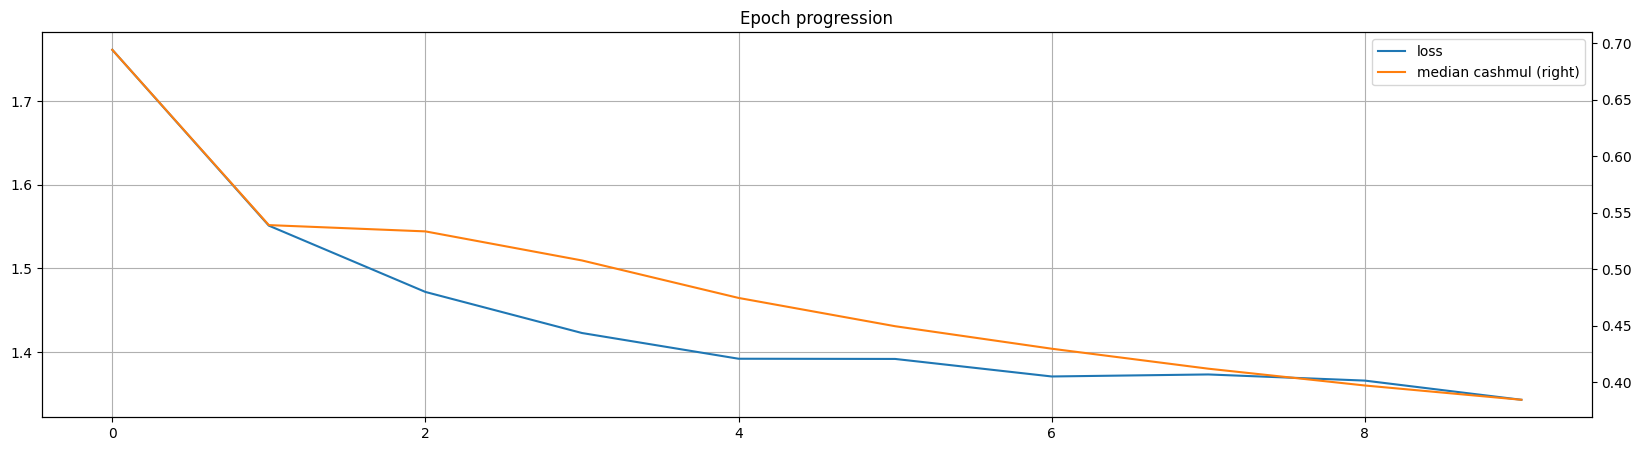

Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-06-01 16.542000     7.355000              0.704000 36.130000   
           2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   

                         asmul   cashmul     model  
cik        snapshot                                 
0000001750 2012-01-01 0.947928 -0.209088  0.751616  
           2012-02-01 0.962655 -0.210137  0.778356  
           2012-03-01 0.968090 -0.180075  0.790768  
           2012-04-01 0.938875 -0.195613  0.741278  
           2012-05-01 0.923114 -0.202602  0.705817  
...                        ...       ...       ...  
0001915657 2025-06-01 0.956651  0.523057  8.838153  
           2025-07-01 1.027790  0.569274 10.047470  
           2025-08-01 1.050378  0.577845 10.747075  
           2025-09-01 1.148742  0.616282 12.444838  
           2025-10-01 1.169060  0.629158 12.800797  

[435085 rows x 7 columns]

In [13]:
model_train(pricing_model)
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

In [14]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),left_index=True,right_index=True,how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']
# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model
snapshot,cik,date,,,,,,,,
2024-05-01,0001018724,2023-12-31,AMZN,527.854000,325.979000,133.367167,175.000000,0.786375,0.397840,142.171073
2024-06-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,176.440000,0.728202,0.445790,143.279236
2024-07-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,193.250000,0.752497,0.452183,157.196056
2024-08-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,186.980000,0.730946,0.490154,151.795302
2024-09-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,178.500000,0.670766,0.514559,144.905387
2024-10-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.330000,0.672386,0.546172,151.402330
2024-11-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.400000,0.678843,0.526545,151.509110
2024-12-01,0001018724,2024-09-30,AMZN,584.626000,325.475000,193.943333,207.890000,0.648208,0.595238,168.926862
2025-01-01,0001018724,2024-09-30,AMZN,584.626000,325.475000,193.943333,219.390000,0.695101,0.504380,178.720174


In [15]:
# Let's see for how many ciks the achieved correlation is perfect and for how many it is not.
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']].rename(columns={'model':'corrcoef'}).set_index('cik')
model_corr.sort_values(by='corrcoef').round(3).value_counts()

corrcoef
1.000000    3426
0.999000      10
Name: count, dtype: int64

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

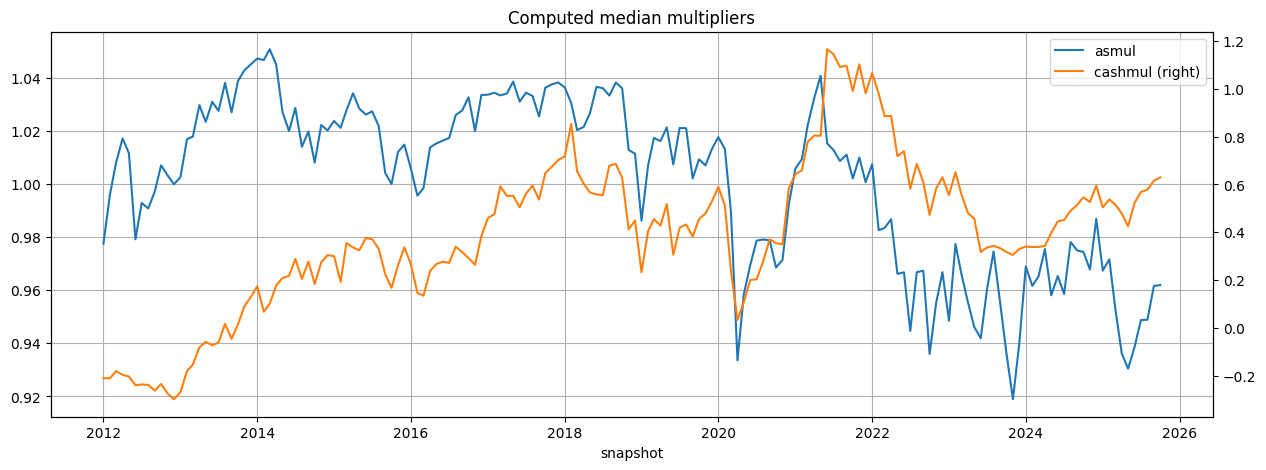

Median asset_multiplier per cik: 0.995101809501648
Median asset_multiplier per snapshot: 1.009416103363037


In [16]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['asmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['cashmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [17]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. We have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. By following the development of the asset_multiplier of each company over time, we can make some estimates if and how much the stock price corresponds to the financial fundamentals.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

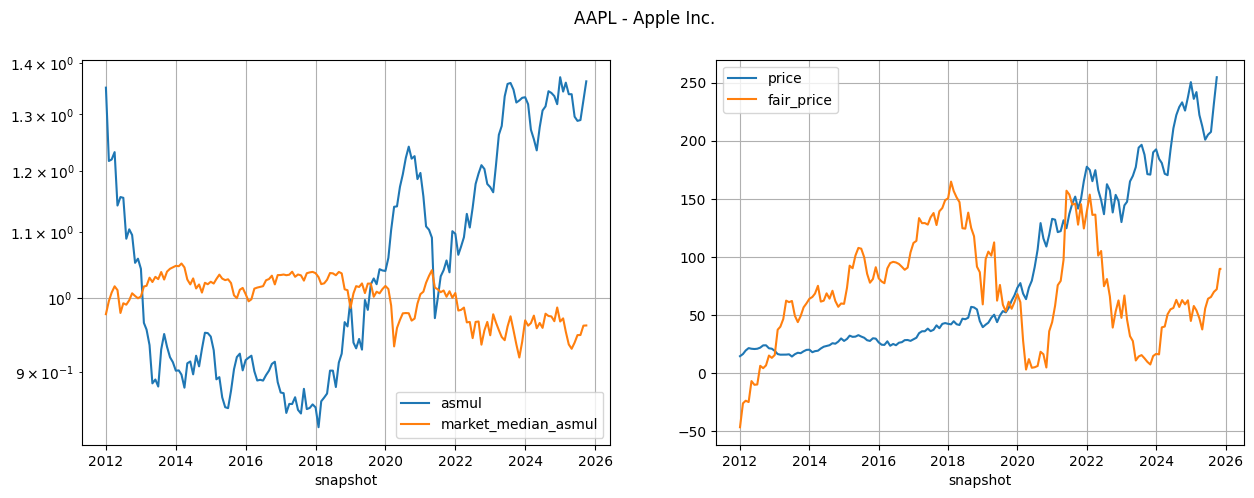

Apple Inc. stock pricing model:
AAPL fair_price = 1.6535 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -166.2358


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000320193,2025-03-29,AAPL,331.233000,264.437000,109.556000,0.577845,1.030253,140.123134,65.459223
2025-09-01,0000320193,2025-06-28,AAPL,331.495000,265.665000,108.565000,0.616282,1.030253,142.765298,69.828067
2025-10-01,0000320193,2025-06-28,AAPL,331.495000,265.665000,108.565000,0.629158,1.030253,144.163229,72.139561
2025-11-01,0000320193,2025-09-27,AAPL,359.241000,285.508000,111.482000,0.629158,1.030253,154.740879,89.629811
2025-11-08,0000320193,2025-09-27,AAPL,359.241000,285.508000,111.482000,0.629158,1.030253,154.740879,89.629811


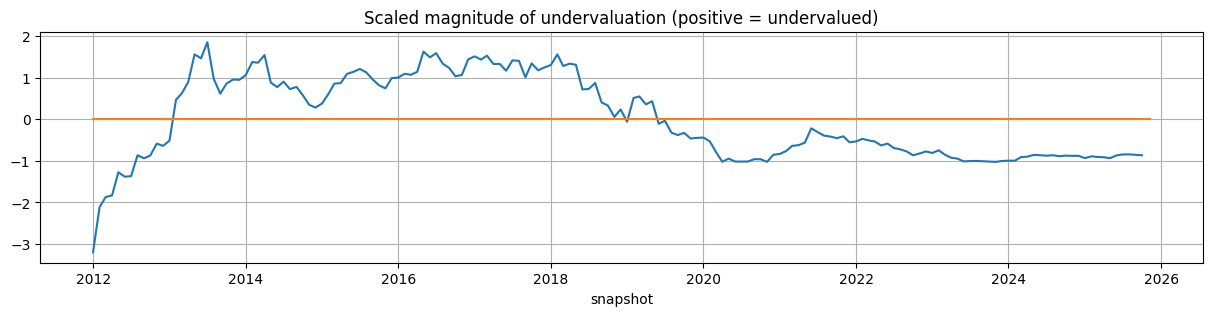

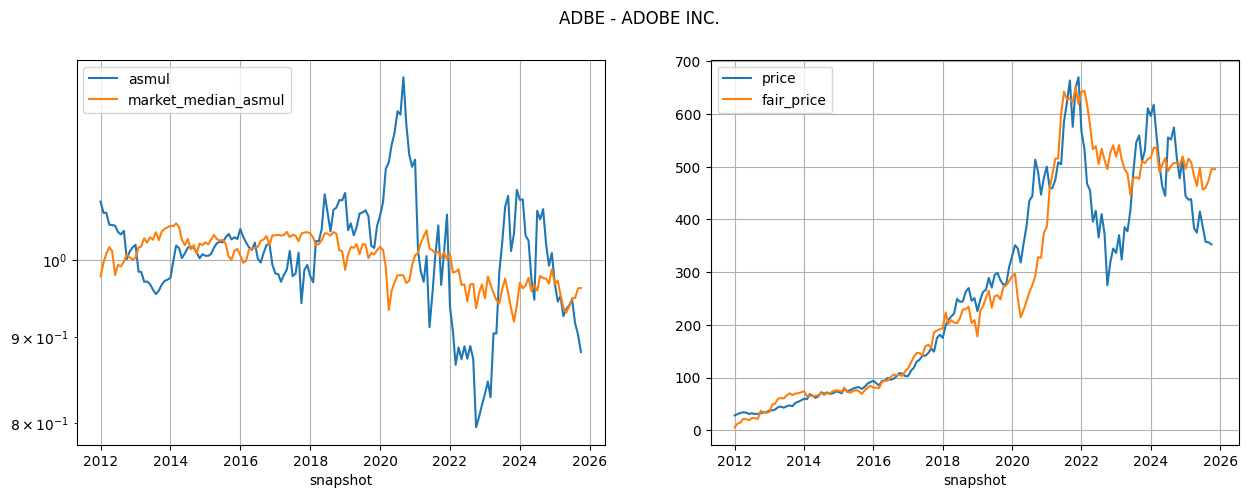

ADOBE INC. stock pricing model:
ADBE fair_price = 37.9216 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -198.4445


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000796343,2025-05-30,ADBE,28.107000,16.659000,9.615000,0.577845,1.012749,17.362319,459.962476
2025-09-01,0000796343,2025-05-30,ADBE,28.107000,16.659000,9.615000,0.616282,1.012749,17.731888,473.977125
2025-10-01,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.629158,1.012749,18.297305,495.418635
2025-11-01,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.629158,1.012749,18.297305,495.418635
2025-11-08,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.629158,1.012749,18.297305,495.418635


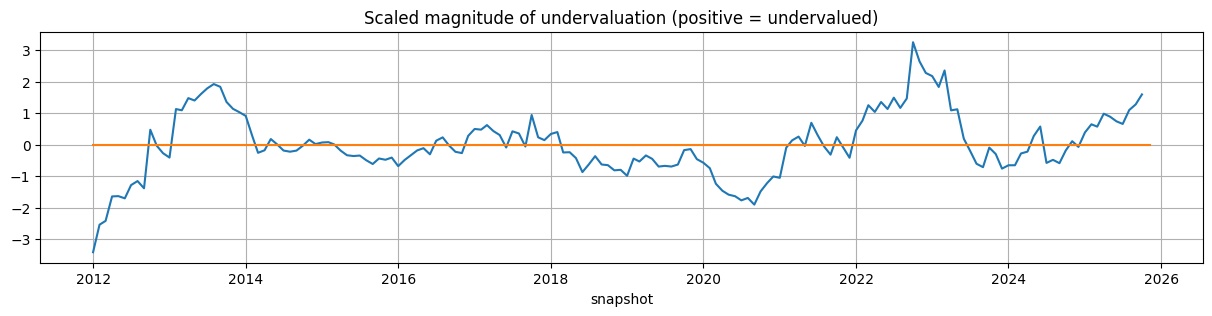

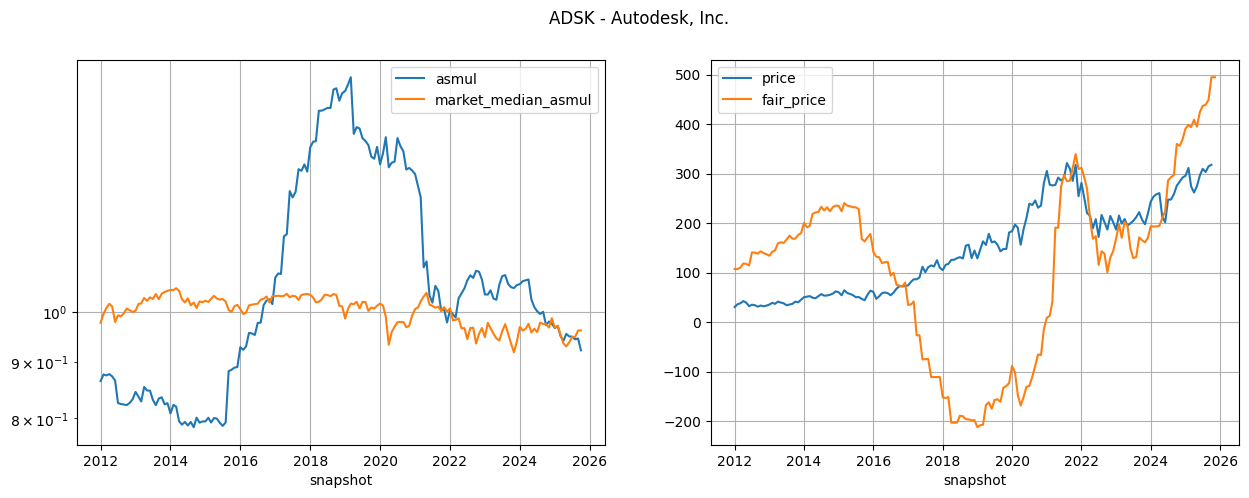

Autodesk, Inc. stock pricing model:
ADSK fair_price = 160.4625 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -178.7881


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000769397,2025-04-30,ADSK,10.585000,7.968000,1.677000,0.577845,1.024954,3.850185,439.022065
2025-09-01,0000769397,2025-04-30,ADSK,10.585000,7.968000,1.677000,0.616282,1.024954,3.914644,449.365212
2025-10-01,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.629158,1.024954,4.197031,494.677823
2025-11-01,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.629158,1.024954,4.197031,494.677823
2025-11-08,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.629158,1.024954,4.197031,494.677823


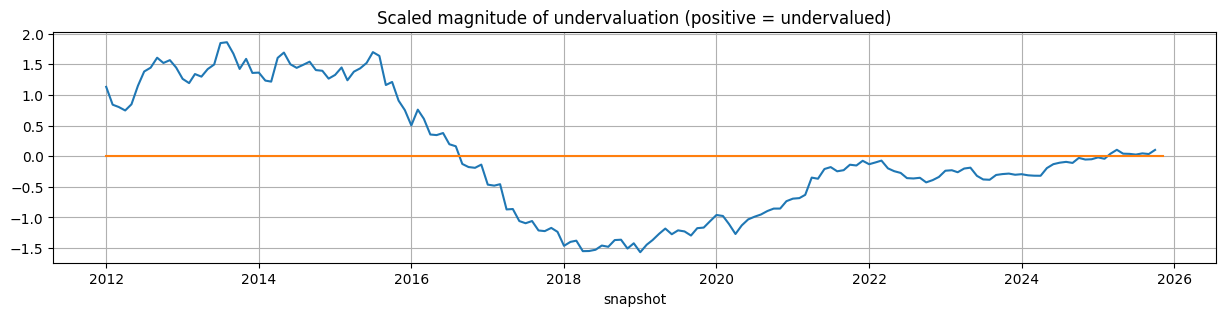

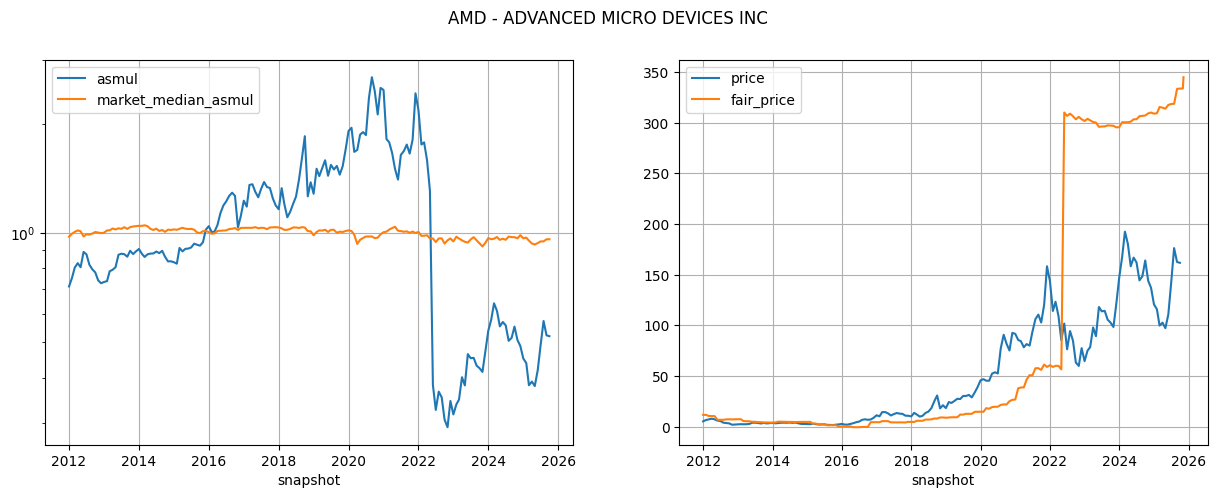

ADVANCED MICRO DEVICES INC stock pricing model:
AMD fair_price = 5.8707 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 4.2434


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000002488,2025-03-29,AMD,71.550000,13.669000,3.459000,0.577845,0.911621,53.556247,318.656252
2025-09-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.616282,0.911621,56.058088,333.343816
2025-10-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.629158,0.911621,56.120886,333.712487
2025-11-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.629158,0.911621,56.120886,333.712487
2025-11-08,0000002488,2025-09-27,AMD,76.891000,16.101000,6.408000,0.629158,0.911621,58.026095,344.897399


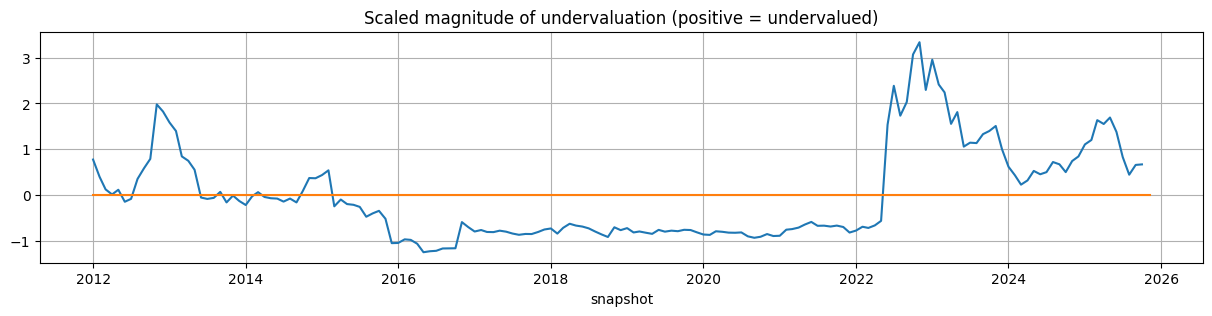

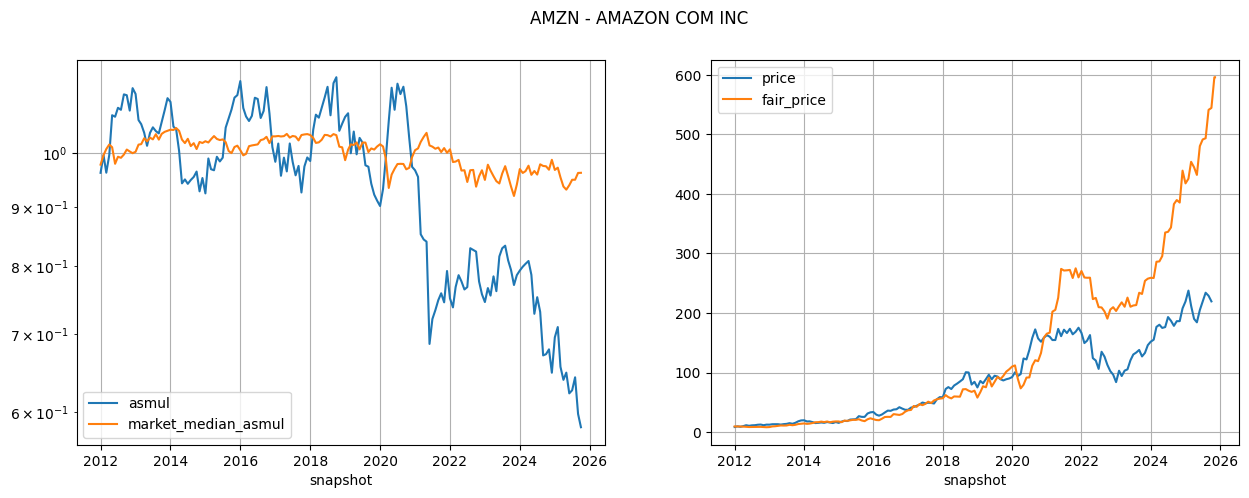

AMAZON COM INC stock pricing model:
AMZN fair_price = 1.214 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 2.4315


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001018724,2025-03-31,AMZN,643.256000,337.389000,199.102833,0.577845,0.974569,404.559247,493.557115
2025-09-01,0001018724,2025-06-30,AMZN,682.170000,348.395000,206.735833,0.616282,0.974569,443.834580,541.236465
2025-10-01,0001018724,2025-06-30,AMZN,682.170000,348.395000,206.735833,0.629158,0.974569,446.496604,544.468100
2025-11-01,0001018724,2025-09-30,AMZN,727.921000,358.290000,219.100167,0.629158,0.974569,488.968254,596.027706
2025-11-08,0001018724,2025-09-30,AMZN,727.921000,358.290000,219.100167,0.629158,0.974569,488.968254,596.027706


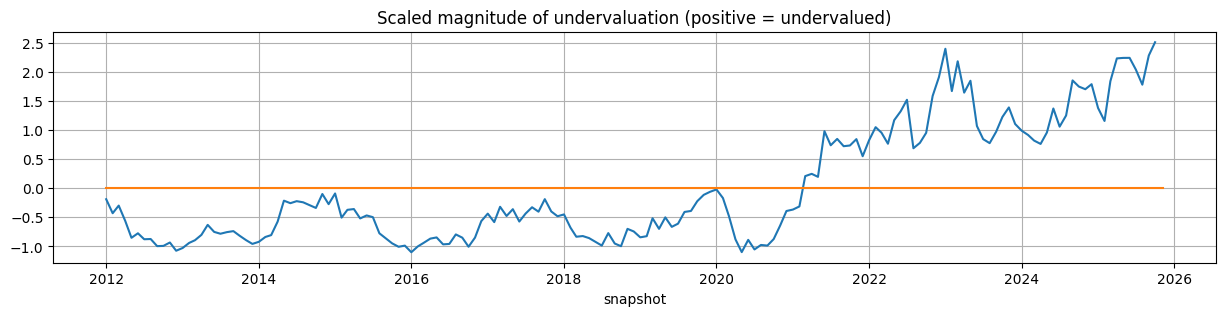

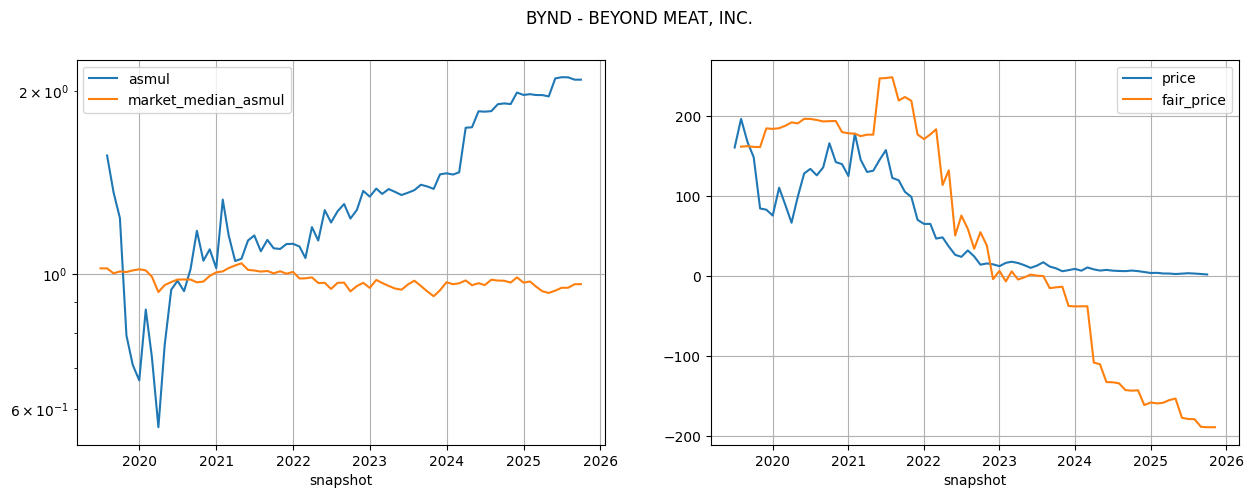

BEYOND MEAT, INC. stock pricing model:
BYND fair_price = 362.7768 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.1198


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001655210,2025-03-29,BYND,0.643830,1.293361,-0.093154,0.577845,1.324825,-0.494227,-179.174475
2025-09-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.616282,1.324825,-0.520337,-188.646536
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.629158,1.324825,-0.521758,-189.162030
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.629158,1.324825,-0.521758,-189.162030
2025-11-08,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.629158,1.324825,-0.521758,-189.162030


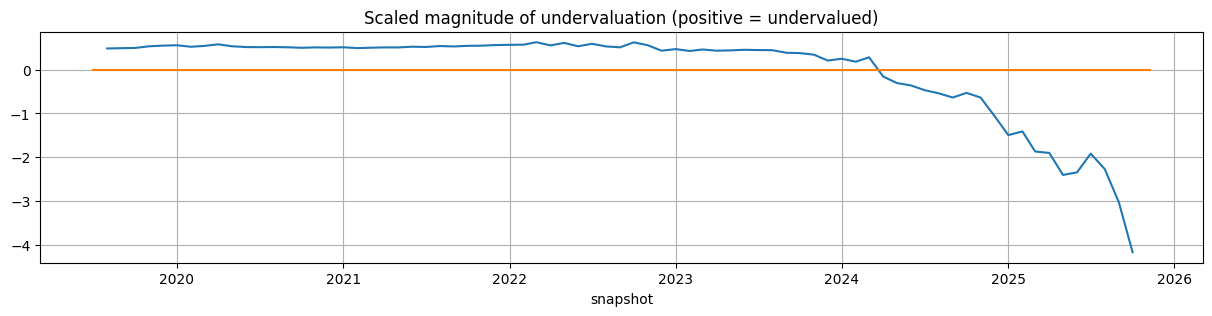

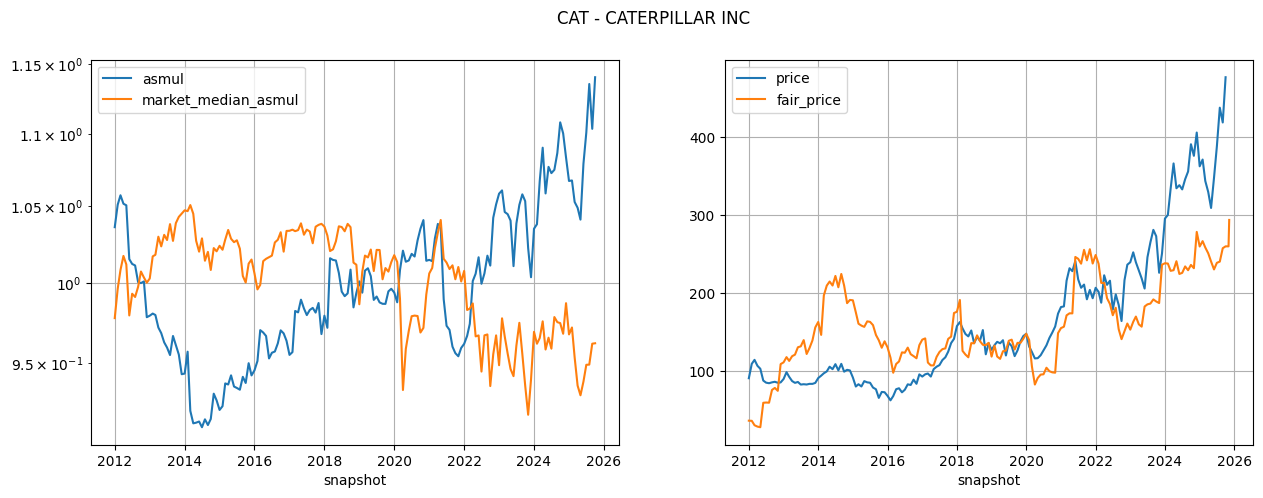

CATERPILLAR INC stock pricing model:
CAT fair_price = 16.3109 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -151.6145


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000018230,2025-03-31,CAT,84.974000,66.904000,11.272000,0.577845,0.993521,24.032947,240.384363
2025-09-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.616282,0.993521,25.086783,257.573361
2025-10-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.629158,0.993521,25.233227,259.961992
2025-11-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.629158,0.993521,25.233227,259.961992
2025-11-08,0000018230,2025-09-30,CAT,93.722000,73.063000,11.541000,0.629158,0.993521,27.312917,293.883603


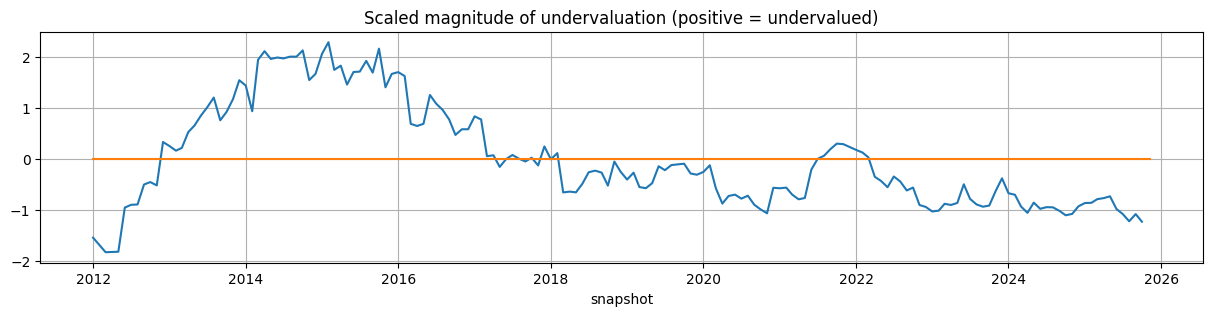

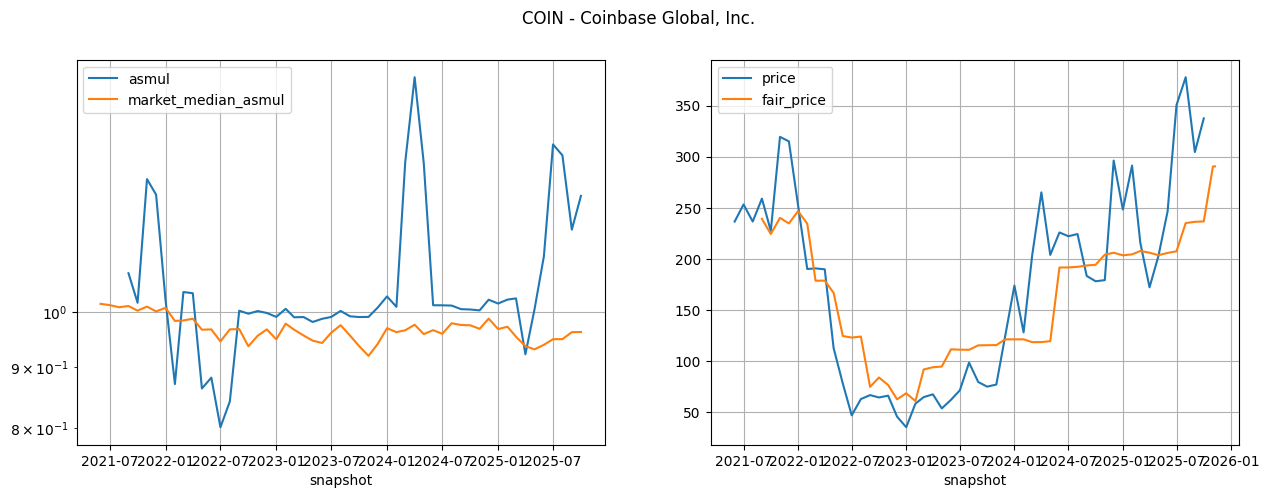

Coinbase Global, Inc. stock pricing model:
COIN fair_price = 17.6396 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.5014


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.577845,1.006822,13.299148,235.093388
2025-09-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.616282,1.006822,13.368599,236.318489
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.629158,1.006822,13.391866,236.728902
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,0.629158,1.006822,16.442103,290.533936
2025-11-08,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,0.629158,1.006822,16.442103,290.533936


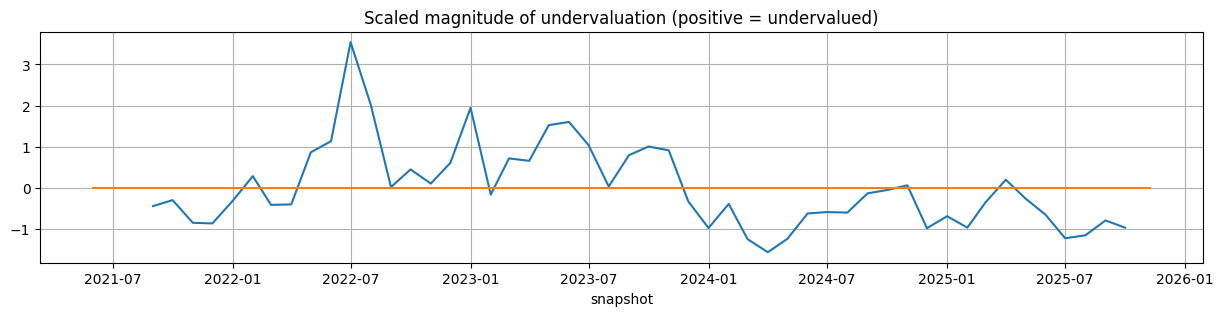

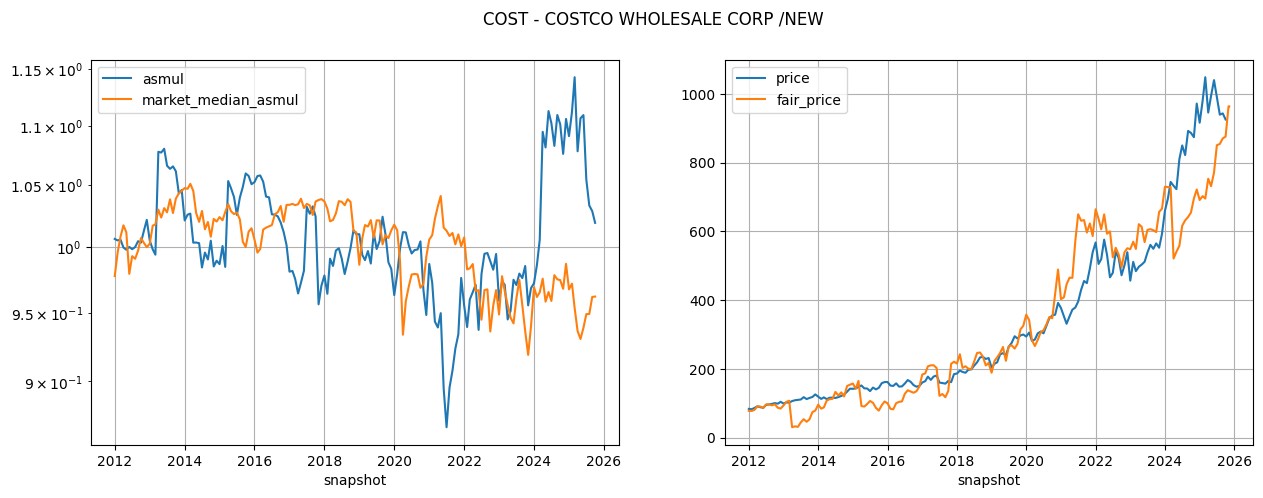

COSTCO WHOLESALE CORP /NEW stock pricing model:
COST fair_price = 33.707 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -301.6543


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.577845,0.999858,34.294560,854.314028
2025-09-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.616282,0.999858,34.772175,870.413005
2025-10-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.629158,0.999858,34.932177,875.806226
2025-11-01,0000909832,2025-08-31,COST,77.099000,47.935000,13.335000,0.629158,0.999858,37.542852,963.804364
2025-11-08,0000909832,2025-08-31,COST,77.099000,47.935000,13.335000,0.629158,0.999858,37.542852,963.804364


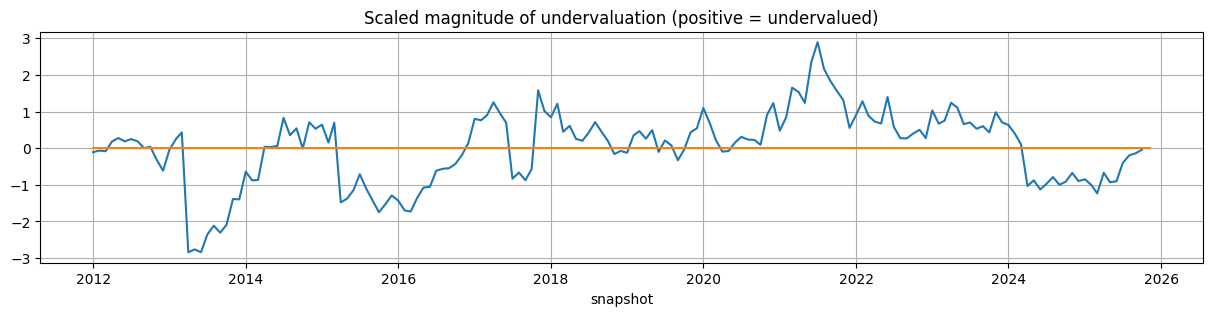

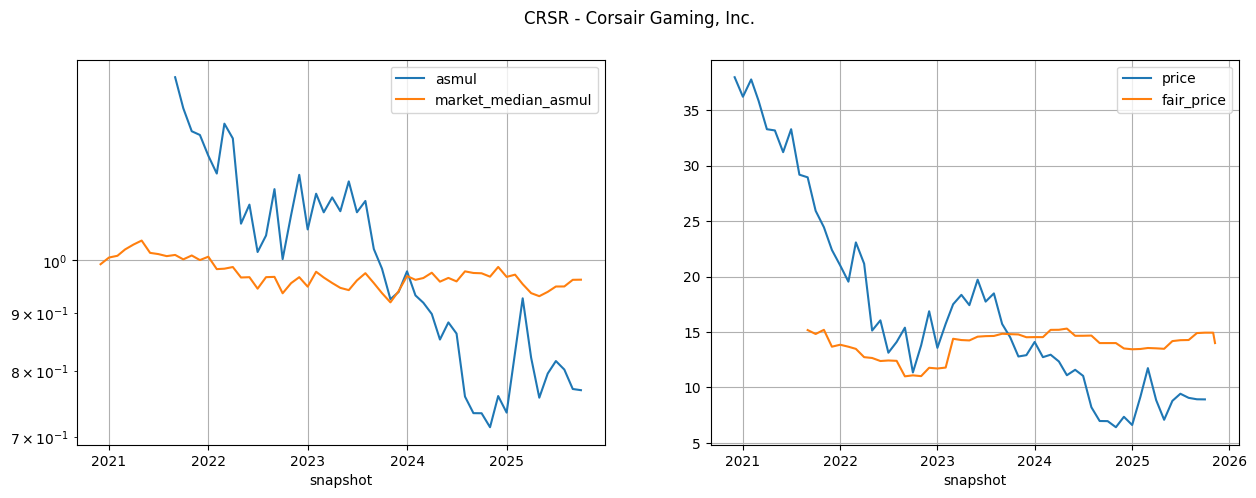

Corsair Gaming, Inc. stock pricing model:
CRSR fair_price = 22.0541 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.006


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001743759,2025-03-31,CRSR,1.239457,0.630700,0.080944,0.577845,0.993171,0.647066,14.276468
2025-09-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.616282,0.993171,0.675423,14.901844
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.629158,0.993171,0.677091,14.938648
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.629158,0.993171,0.677091,14.938648
2025-11-08,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,0.629158,0.993171,0.634518,13.999737


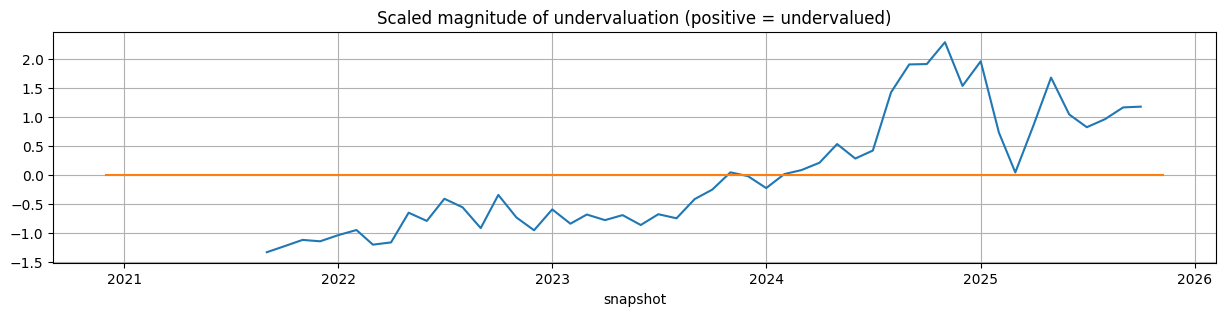

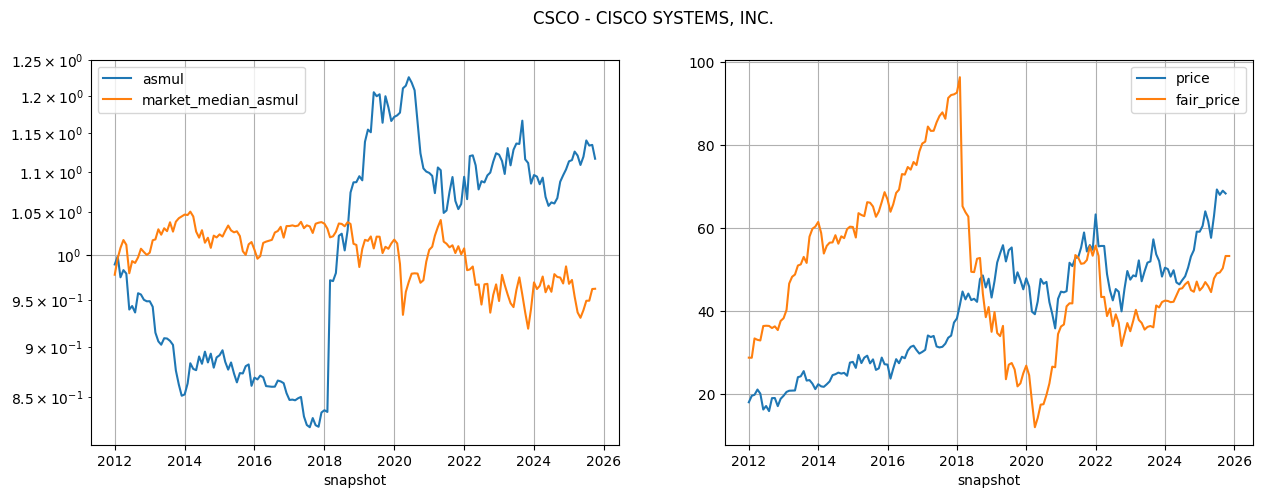

CISCO SYSTEMS, INC. stock pricing model:
CSCO fair_price = 1.9286 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -66.7549


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000858877,2025-04-26,CSCO,119.782000,73.847000,13.689000,0.577845,1.053151,60.211714,49.369543
2025-09-01,0000858877,2025-04-26,CSCO,119.782000,73.847000,13.689000,0.616282,1.053151,60.737874,50.384297
2025-10-01,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.629158,1.053151,62.272593,53.344160
2025-11-01,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.629158,1.053151,62.272593,53.344160
2025-11-08,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.629158,1.053151,62.272593,53.344160


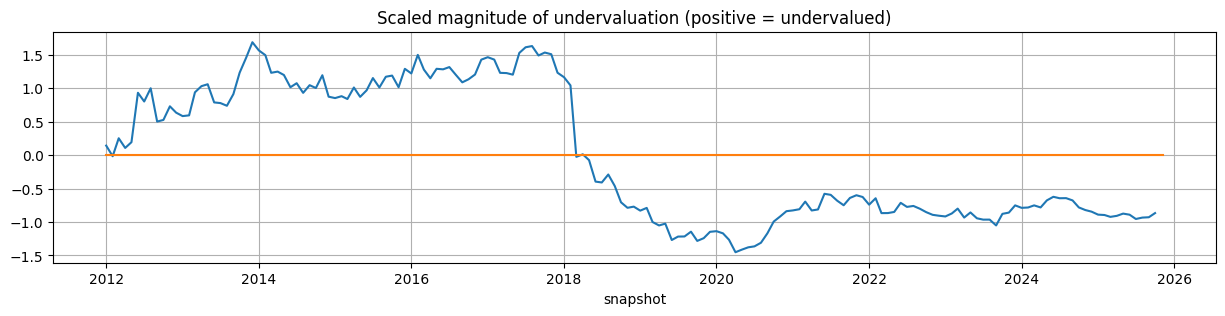

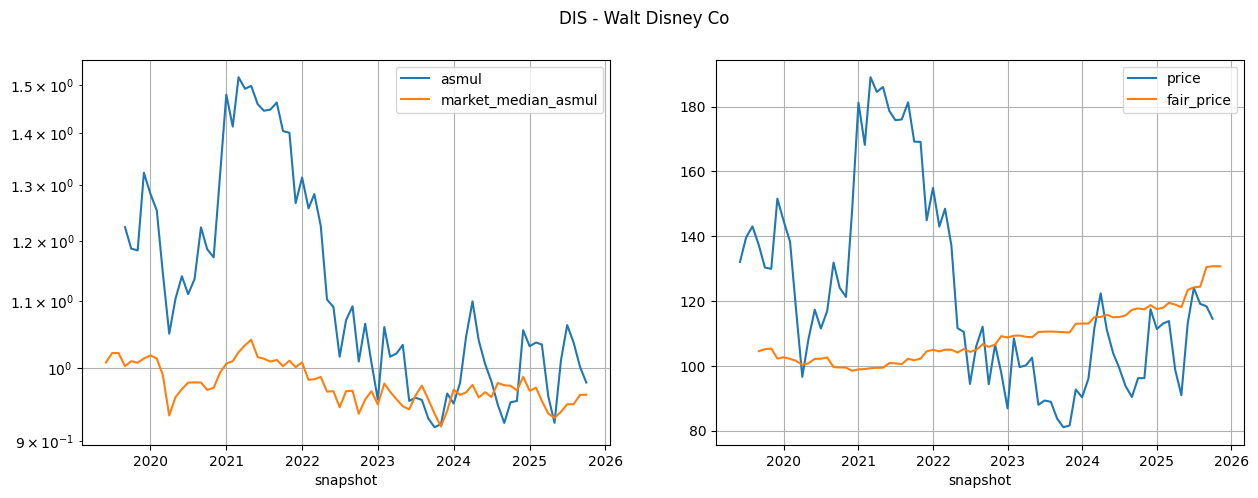

Walt Disney Co stock pricing model:
DIS fair_price = 0.9823 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.7076


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001744489,2025-03-29,DIS,195.833000,91.494000,18.078000,0.577845,1.064068,127.331906,124.375593
2025-09-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.616282,1.064068,133.540246,130.474293
2025-10-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.629158,1.064068,133.786766,130.716459
2025-11-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.629158,1.064068,133.786766,130.716459
2025-11-08,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.629158,1.064068,133.786766,130.716459


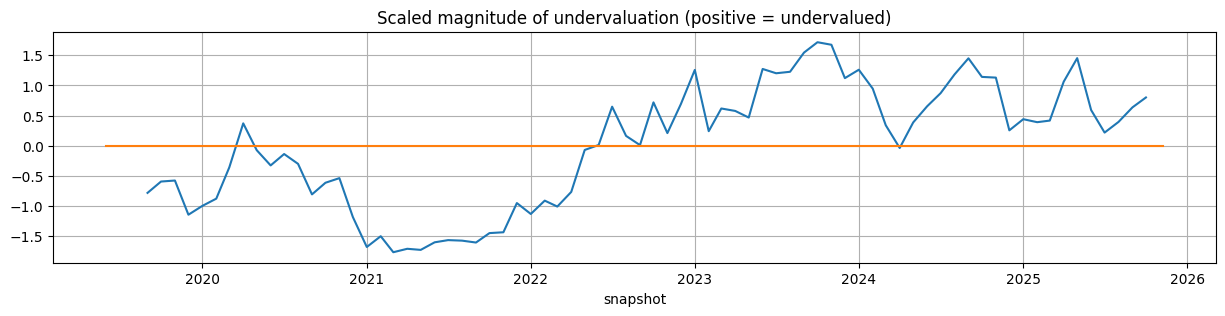

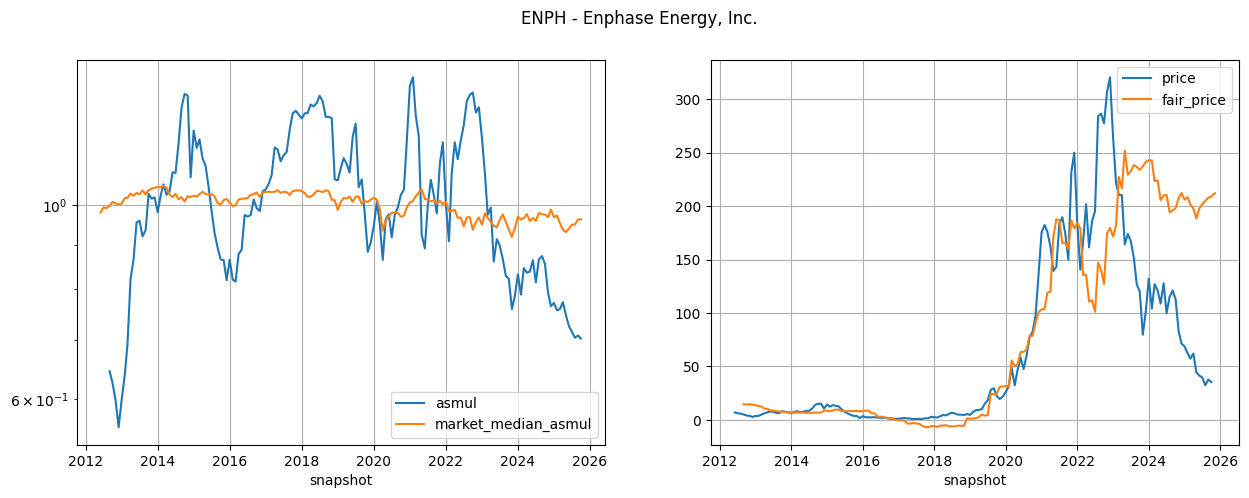

Enphase Energy, Inc. stock pricing model:
ENPH fair_price = 181.808 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.5108


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.577845,1.003587,1.130385,205.002263
2025-09-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.616282,1.003587,1.146239,207.884666
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.629158,1.003587,1.151551,208.850283
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.629158,1.003587,1.168157,211.869420
2025-11-08,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.629158,1.003587,1.168157,211.869420


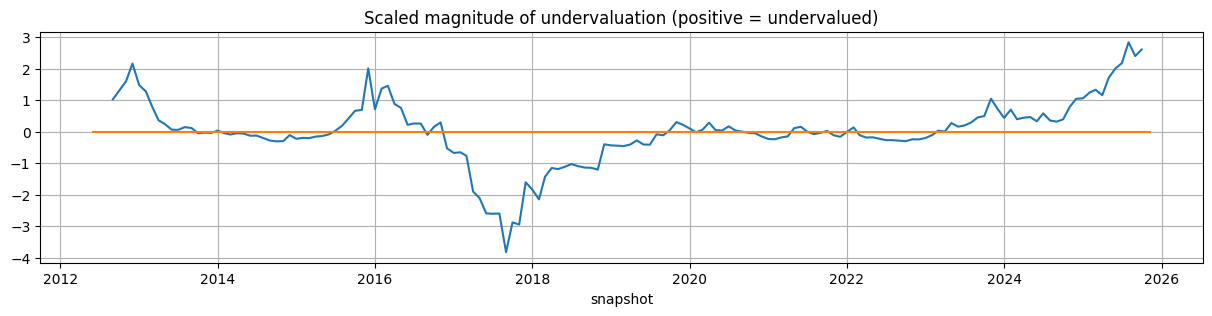

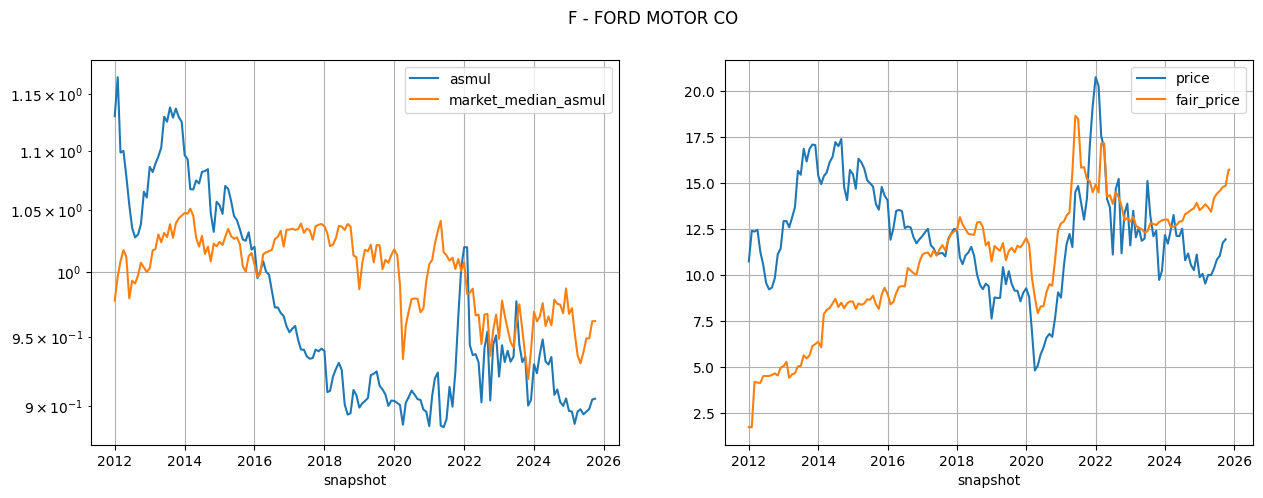

FORD MOTOR CO stock pricing model:
F fair_price = 0.2901 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 3.5568


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.577845,0.939448,38.036988,14.591742
2025-09-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.616282,0.939448,38.749066,14.798323
2025-10-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.629158,0.939448,38.987615,14.867529
2025-11-01,0000037996,2025-09-30,F,300.990000,253.598000,20.426000,0.629158,0.939448,42.017551,15.746547
2025-11-08,0000037996,2025-09-30,F,300.990000,253.598000,20.426000,0.629158,0.939448,42.017551,15.746547


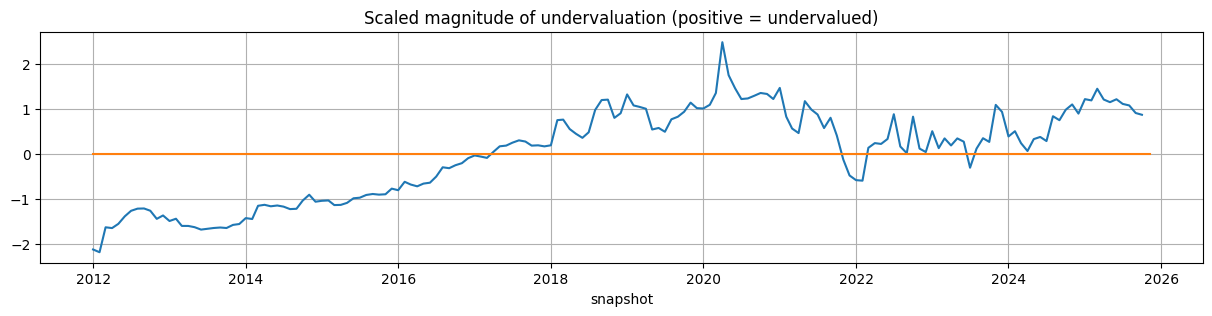

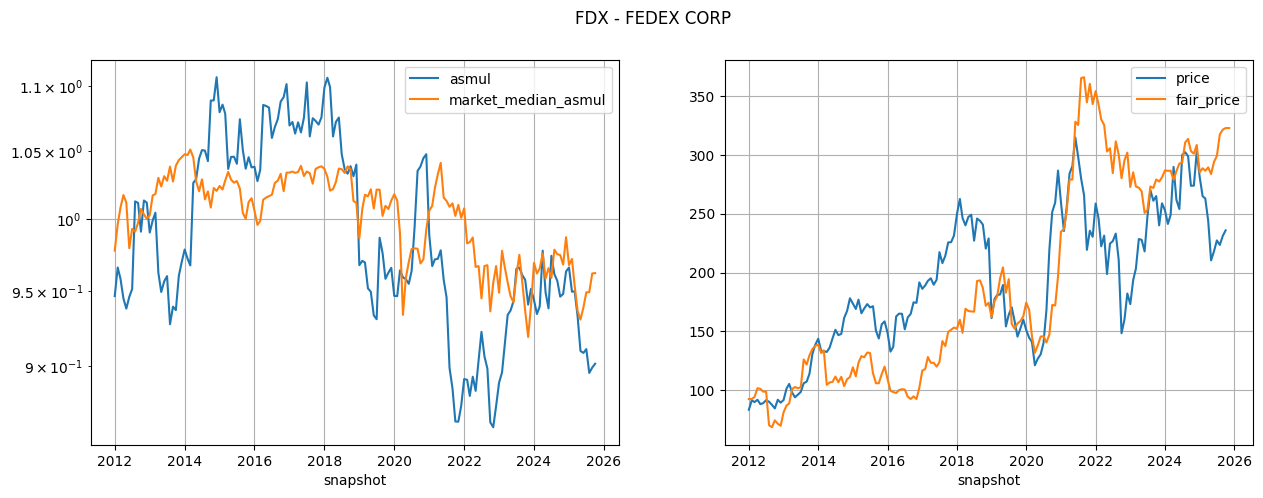

FEDEX CORP stock pricing model:
FDX fair_price = 14.7584 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -116.068


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001048911,2025-05-31,FDX,87.627000,59.553000,7.036000,0.577845,0.968349,29.366245,317.330606
2025-09-01,0001048911,2025-05-31,FDX,87.627000,59.553000,7.036000,0.616282,0.968349,29.636686,321.321876
2025-10-01,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.629158,0.968349,29.732137,322.730578
2025-11-01,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.629158,0.968349,29.732137,322.730578
2025-11-08,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.629158,0.968349,29.732137,322.730578


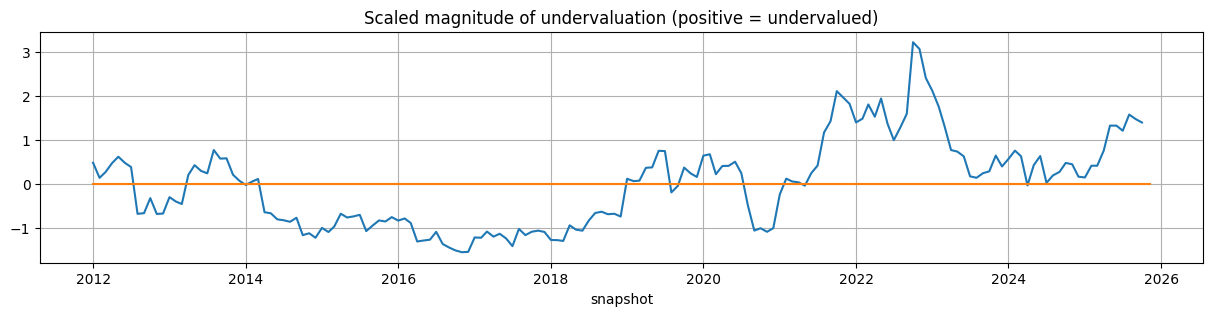

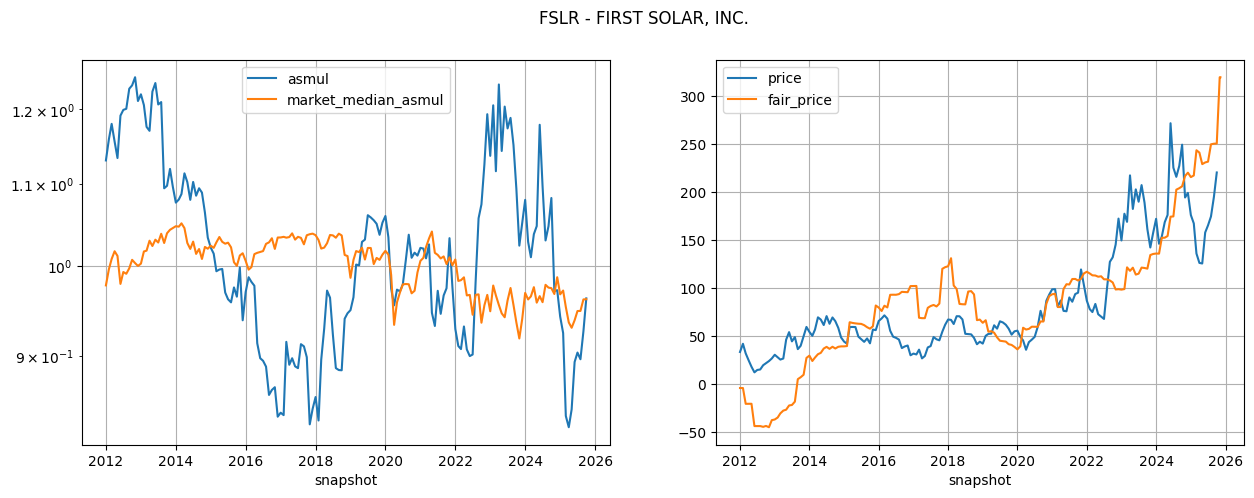

FIRST SOLAR, INC. stock pricing model:
FSLR fair_price = 52.7028 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -214.8601


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.577845,1.007653,8.817223,249.832051
2025-09-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.616282,1.007653,8.828710,250.437452
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.629158,1.007653,8.832558,250.640264
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,0.629158,1.007653,10.141455,319.622796
2025-11-08,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,0.629158,1.007653,10.141455,319.622796


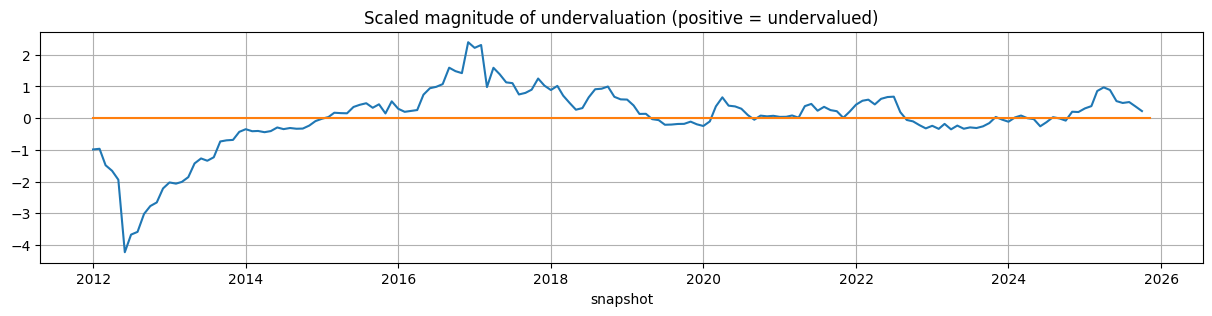

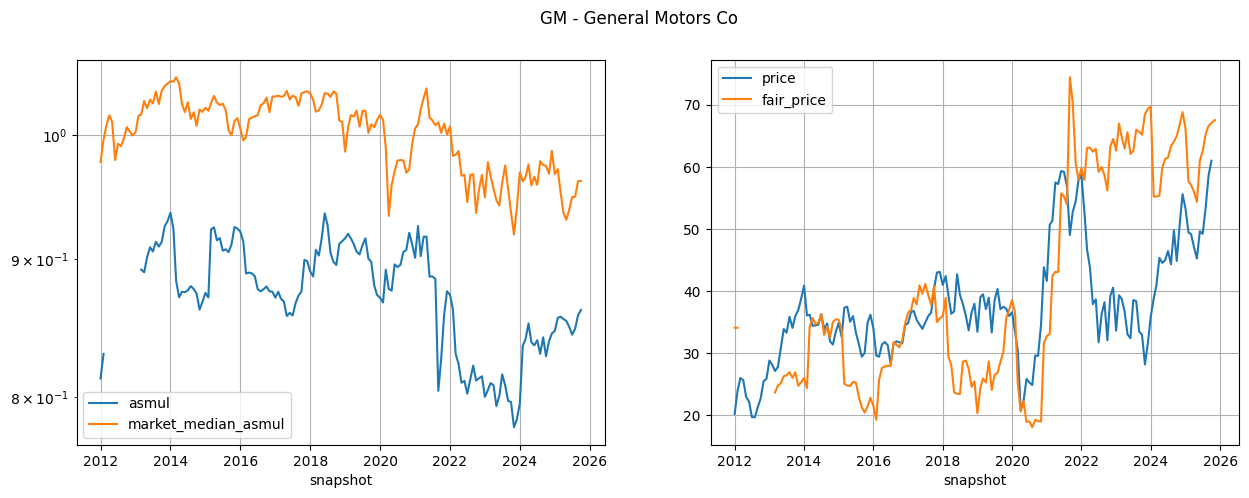

General Motors Co stock pricing model:
GM fair_price = 1.4707 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0073


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.577845,0.876046,44.343524,65.222185
2025-09-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.616282,0.876046,45.264852,66.577160
2025-10-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.629158,0.876046,45.573500,67.031082
2025-11-01,0001467858,2025-09-30,GM,288.168000,221.794000,24.212000,0.629158,0.876046,45.887485,67.492851
2025-11-08,0001467858,2025-09-30,GM,288.168000,221.794000,24.212000,0.629158,0.876046,45.887485,67.492851


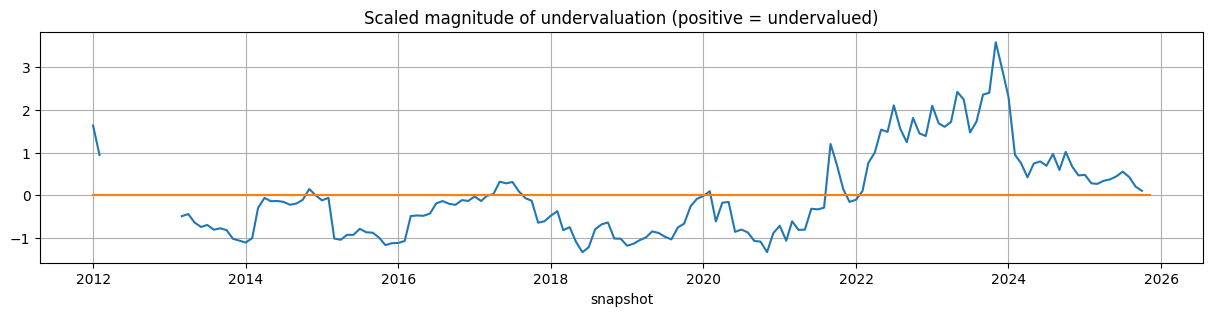

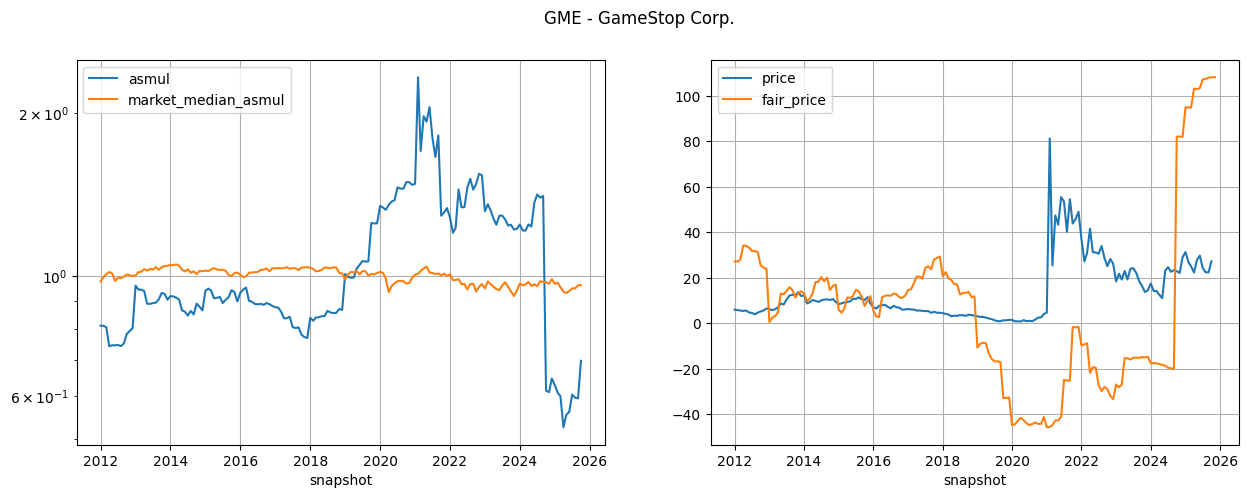

GameStop Corp. stock pricing model:
GME fair_price = 34.7002 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -54.5995


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001326380,2025-05-03,GME,7.502600,2.515200,0.448000,0.577845,0.922746,4.666669,107.334697
2025-09-01,0001326380,2025-05-03,GME,7.502600,2.515200,0.448000,0.616282,0.922746,4.683888,107.932222
2025-10-01,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.629158,0.922746,4.690075,108.146880
2025-11-01,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.629158,0.922746,4.690075,108.146880
2025-11-08,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.629158,0.922746,4.690075,108.146880


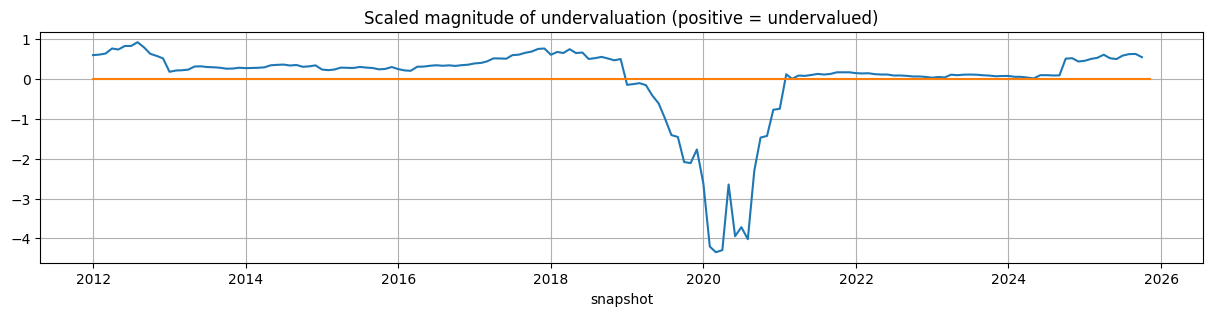

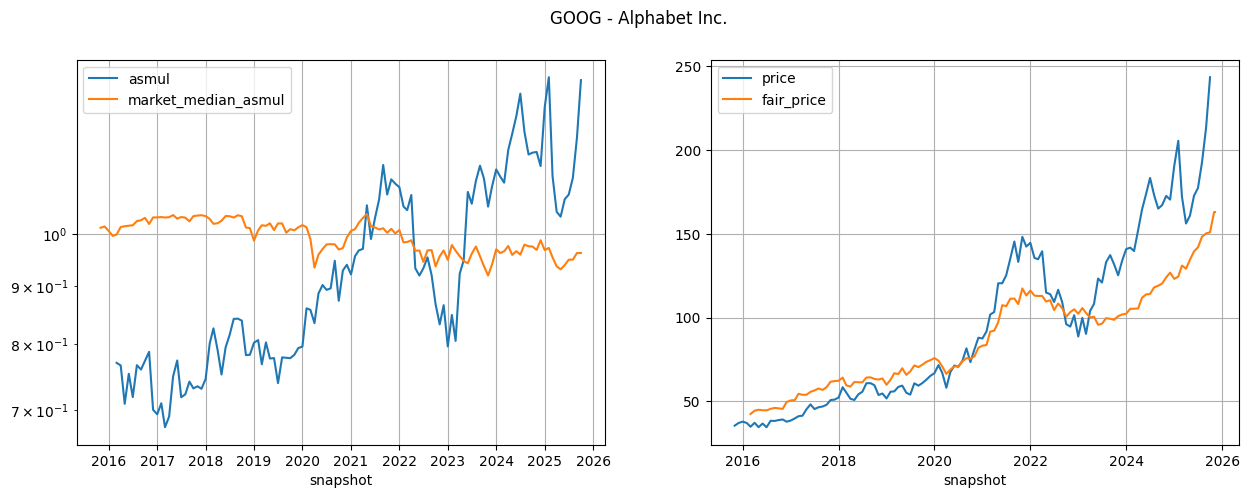

Alphabet Inc. stock pricing model:
GOOG fair_price = 0.3865 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.2916


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.577845,0.889242,384.572161,148.331470
2025-09-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.616282,0.889242,389.711456,150.317620
2025-10-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.629158,0.889242,391.433141,150.982988
2025-11-01,0001652044,2025-09-30,GOOG,536.469000,149.602000,151.424000,0.629158,0.889242,422.718464,163.073624
2025-11-08,0001652044,2025-09-30,GOOG,536.469000,149.602000,151.424000,0.629158,0.889242,422.718464,163.073624


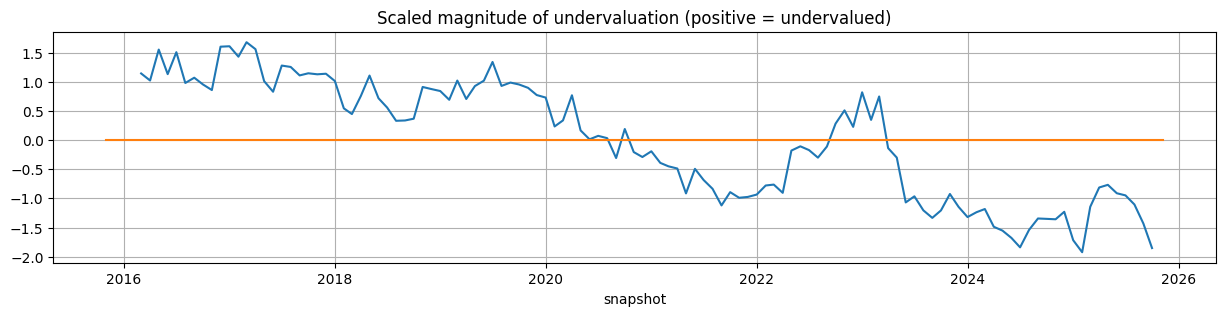

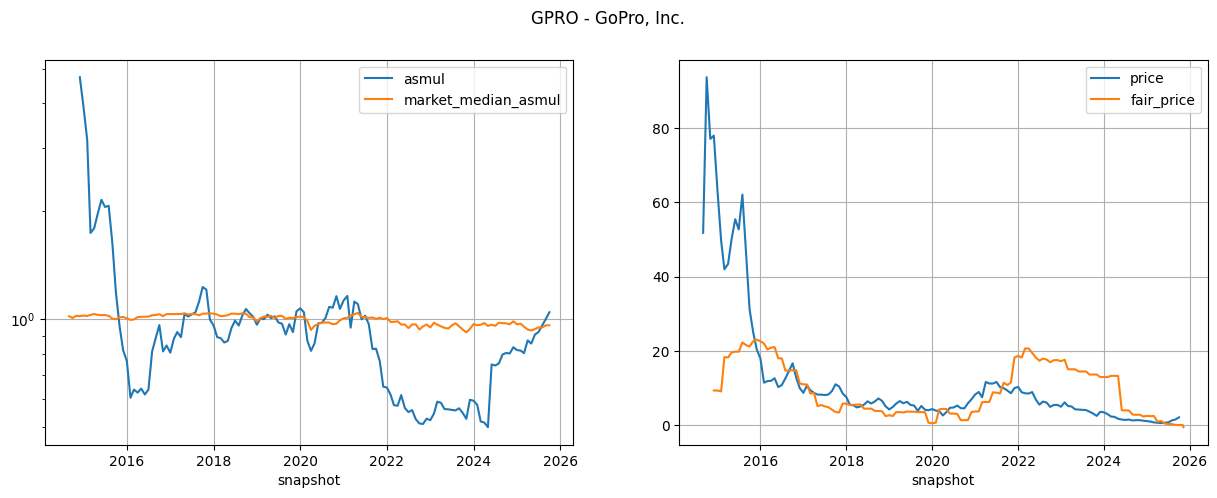

GoPro, Inc. stock pricing model:
GPRO fair_price = 30.3572 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.0272


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001500435,2025-03-31,GPRO,0.462510,0.352530,-0.083924,0.577845,0.890732,0.010948,0.305102
2025-09-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.616282,0.890732,0.003248,0.071353
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.629158,0.890732,0.002272,0.041732
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.629158,0.890732,0.002272,0.041732
2025-11-08,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.629158,0.890732,-0.016970,-0.542411


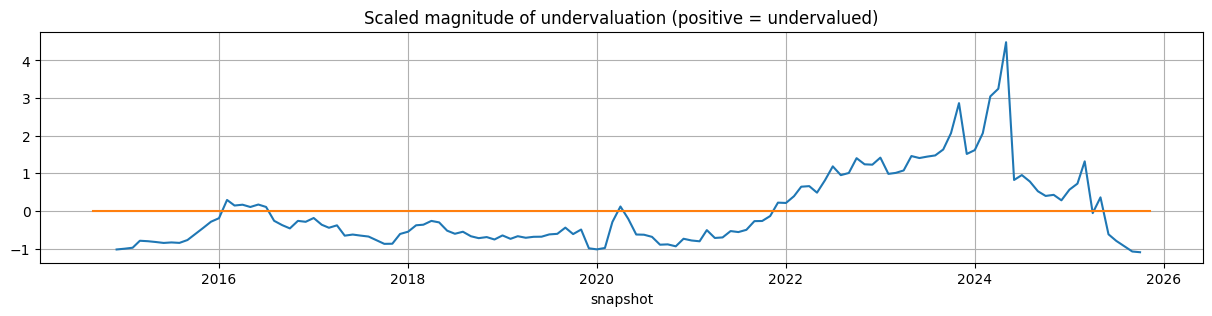

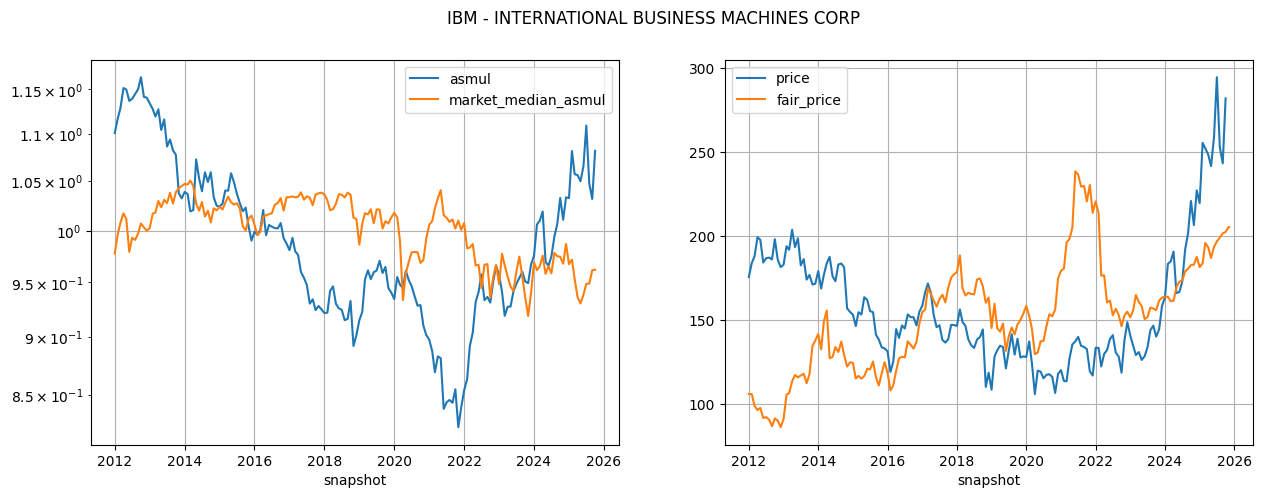

INTERNATIONAL BUSINESS MACHINES CORP stock pricing model:
IBM fair_price = 4.9804 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 42.4667


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.577845,0.975069,31.479627,199.246717
2025-09-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.616282,0.975069,31.990143,201.789274
2025-10-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.629158,0.975069,32.161168,202.641041
2025-11-01,0000051143,2025-09-30,IBM,146.312000,118.407000,13.483000,0.629158,0.975069,32.740296,205.525309
2025-11-08,0000051143,2025-09-30,IBM,146.312000,118.407000,13.483000,0.629158,0.975069,32.740296,205.525309


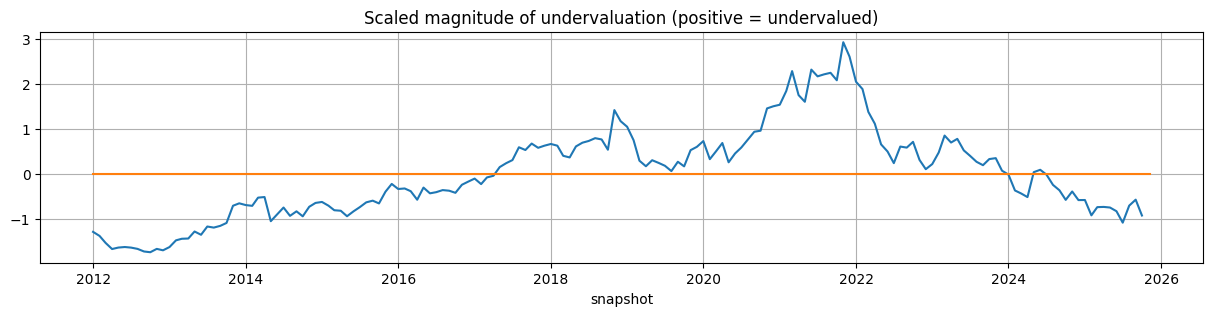

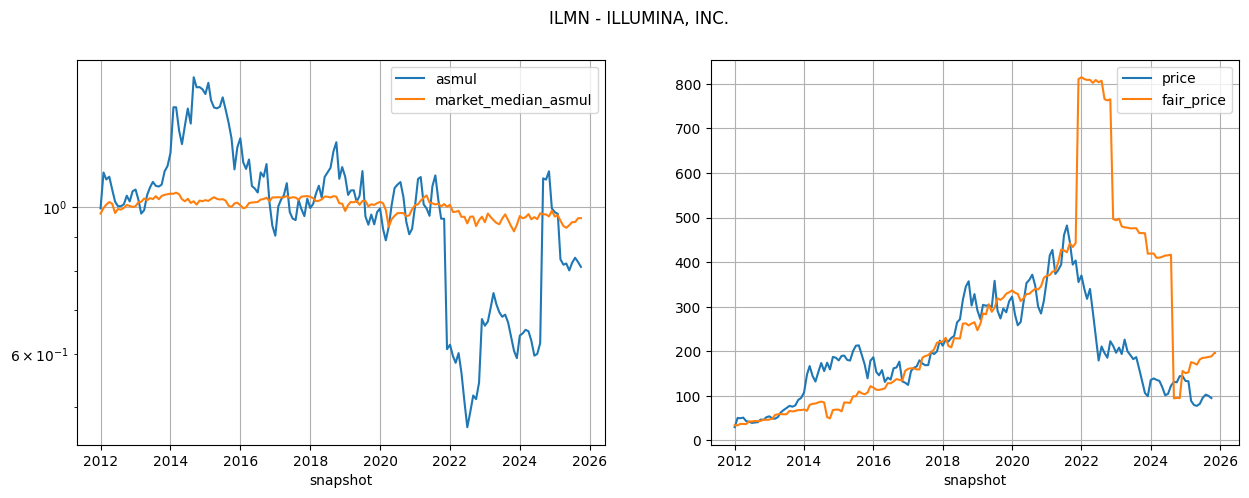

ILLUMINA, INC. stock pricing model:
ILMN fair_price = 73.5532 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -40.6099


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001110803,2025-03-30,ILMN,6.182000,3.814000,1.000000,0.577845,1.021564,3.079156,185.871775
2025-09-01,0001110803,2025-06-29,ILMN,6.087000,3.829000,1.154000,0.616282,1.021564,3.100452,187.438126
2025-10-01,0001110803,2025-06-29,ILMN,6.087000,3.829000,1.154000,0.629158,1.021564,3.115311,188.531084
2025-11-01,0001110803,2025-09-28,ILMN,6.177000,3.796000,1.122000,0.629158,1.021564,3.220119,196.240022
2025-11-08,0001110803,2025-09-28,ILMN,6.177000,3.796000,1.122000,0.629158,1.021564,3.220119,196.240022


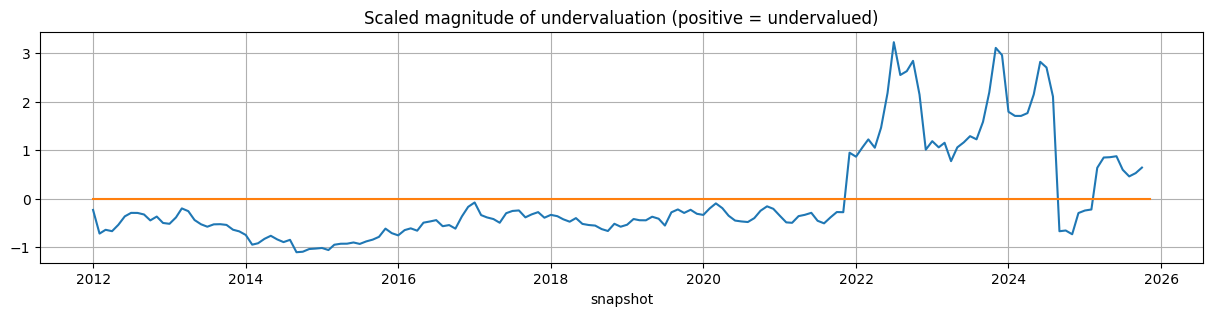

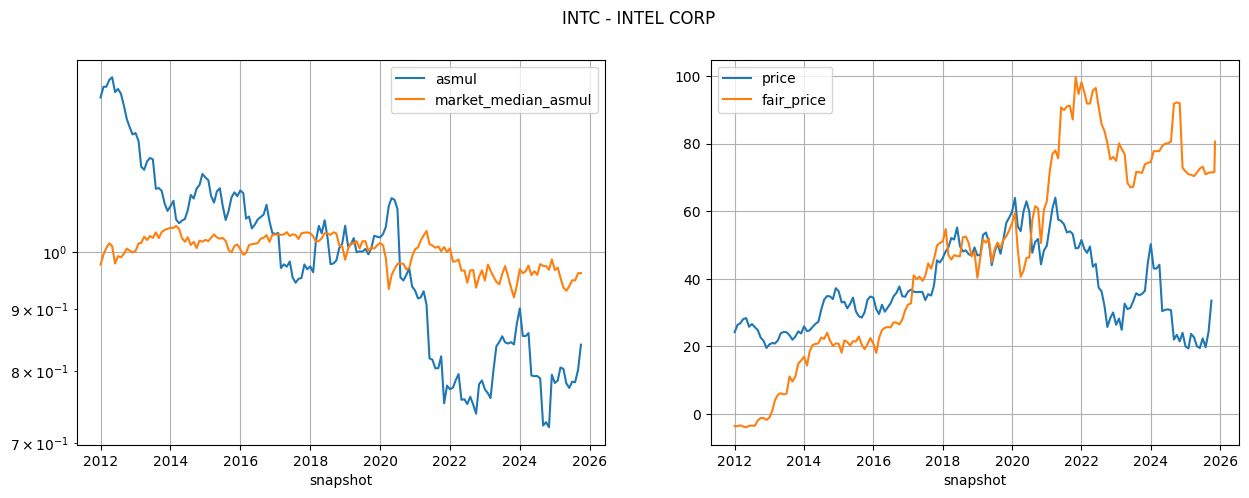

INTEL CORP stock pricing model:
INTC fair_price = 1.1887 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -53.995


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.577845,1.007077,105.071295,70.907315
2025-09-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.616282,1.007077,105.458814,71.367973
2025-10-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.629158,1.007077,105.588634,71.522296
2025-11-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.629158,1.007077,105.588634,71.522296
2025-11-08,0000050863,2025-09-27,INTC,204.514000,98.138000,8.574000,0.629158,1.007077,113.217745,80.591313


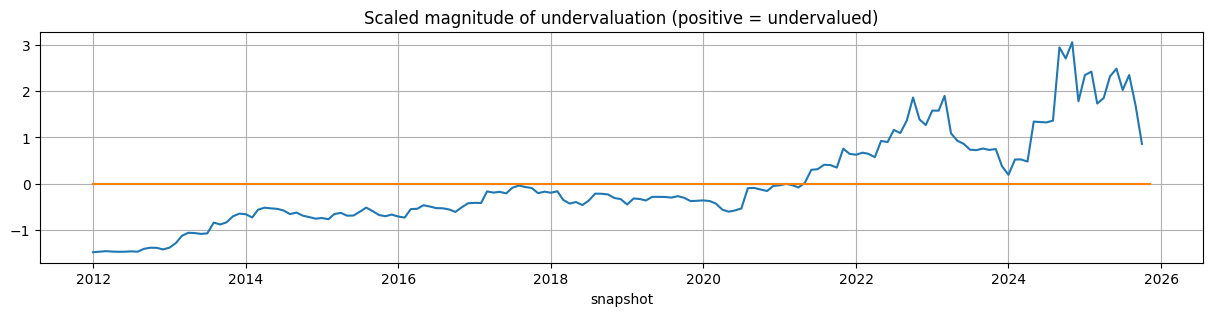

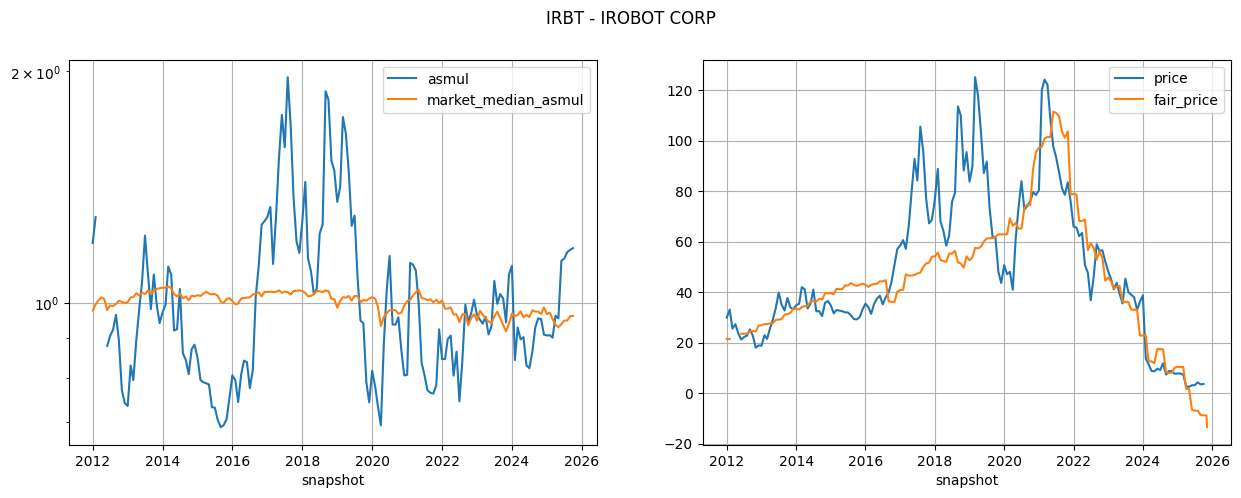

IROBOT CORP stock pricing model:
IRBT fair_price = 109.9485 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.2038


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001159167,2025-03-29,IRBT,0.461509,0.462302,-0.061119,0.577845,0.943543,-0.062166,-7.038838
2025-09-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.616282,0.943543,-0.077706,-8.747504
2025-10-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.629158,0.943543,-0.078602,-8.846048
2025-11-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.629158,0.943543,-0.078602,-8.846048
2025-11-08,0001159167,2025-09-27,IRBT,0.481573,0.508458,-0.106949,0.629158,0.943543,-0.121361,-13.547271


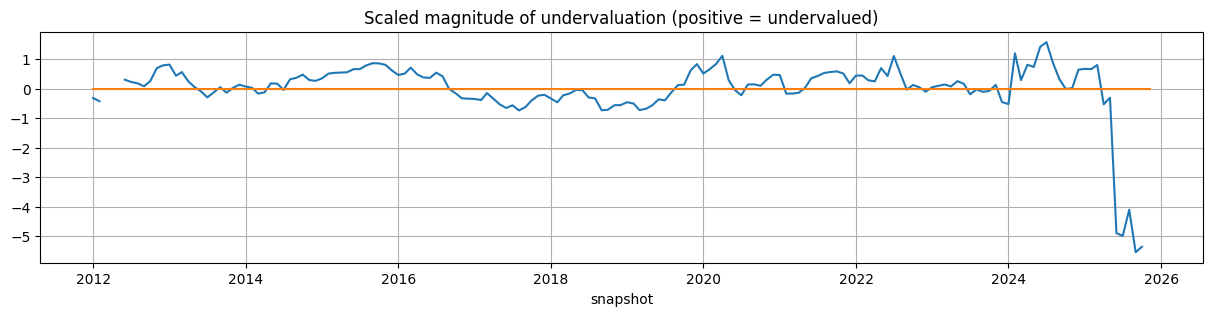

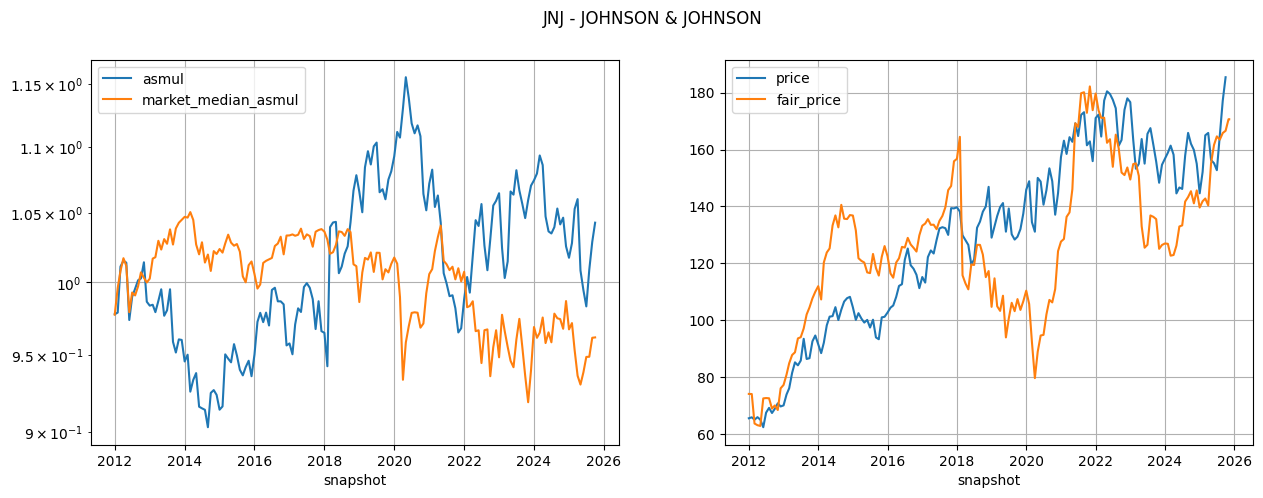

JOHNSON & JOHNSON stock pricing model:
JNJ fair_price = 2.6391 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -82.0815


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.577845,1.006543,93.045039,163.478241
2025-09-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.616282,1.006543,93.930160,165.814207
2025-10-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.629158,1.006543,94.226679,166.596764
2025-11-01,0000200406,2025-09-28,JNJ,192.816000,113.539000,24.204000,0.629158,1.006543,95.766820,170.661426
2025-11-08,0000200406,2025-09-28,JNJ,192.816000,113.539000,24.204000,0.629158,1.006543,95.766820,170.661426


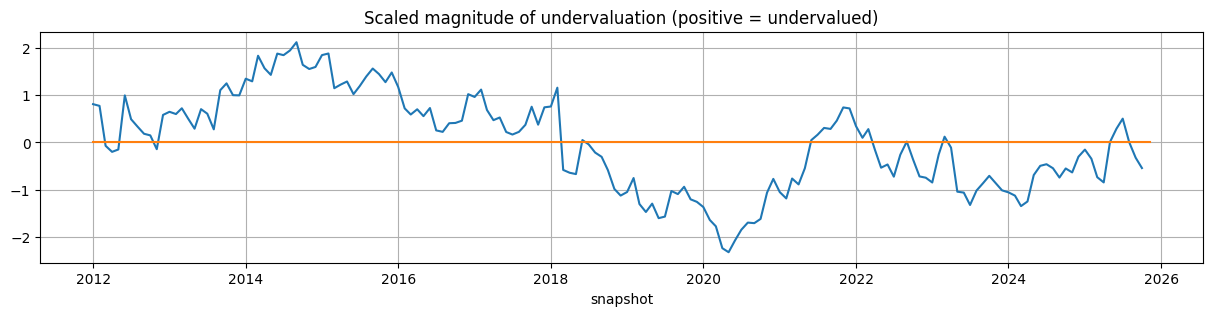

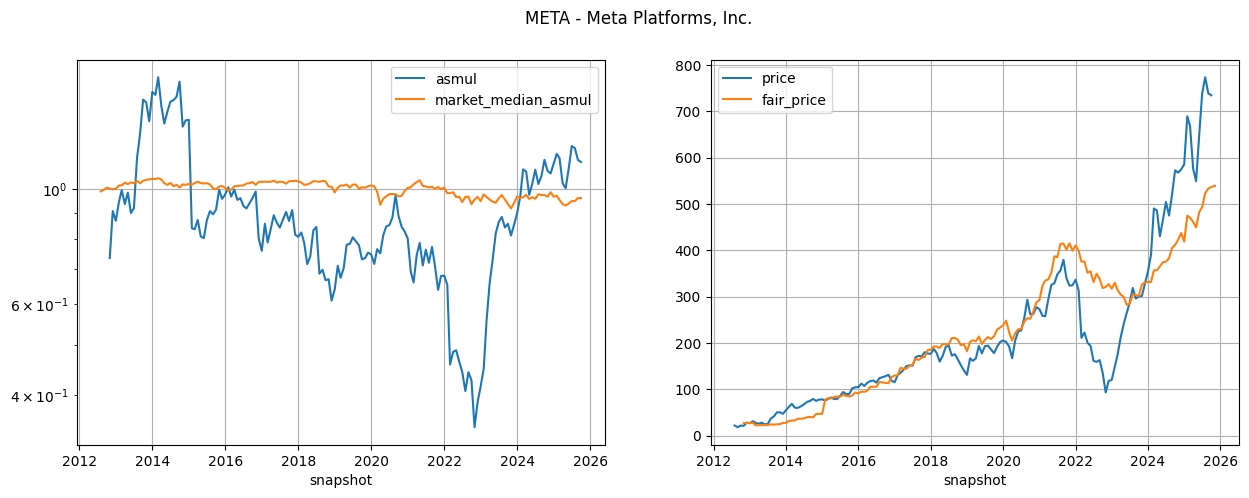

Meta Platforms, Inc. stock pricing model:
META fair_price = 2.4705 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.8872


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.577845,0.857761,212.259003,523.501004
2025-09-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.616282,0.857761,216.191040,533.215145
2025-10-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.629158,0.857761,217.508288,536.469421
2025-11-01,0001326801,2025-09-30,META,303.844000,109.778000,107.574000,0.629158,0.857761,218.528727,538.990426
2025-11-08,0001326801,2025-09-30,META,303.844000,109.778000,107.574000,0.629158,0.857761,218.528727,538.990426


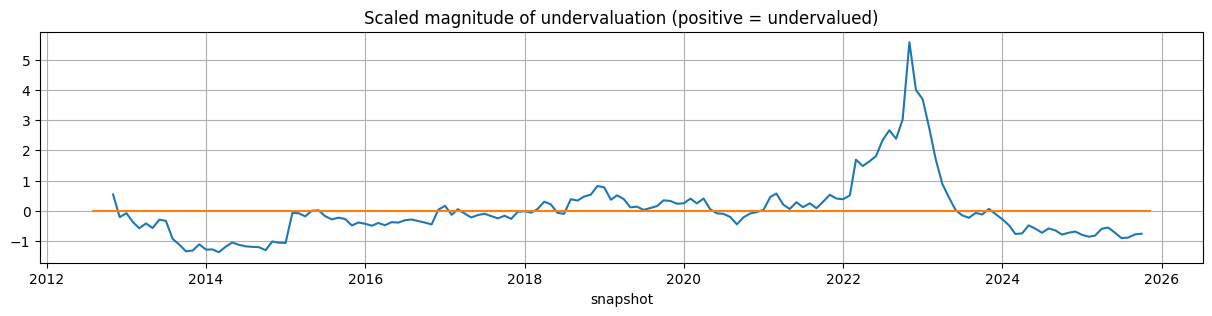

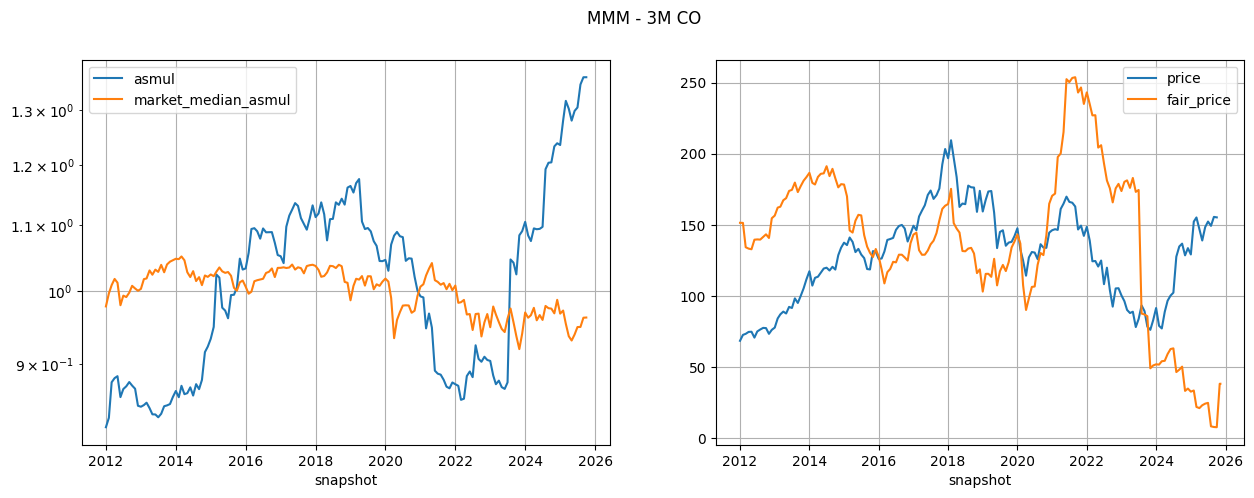

3M CO stock pricing model:
MMM fair_price = 11.9771 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -53.0594


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.577845,1.036822,5.109815,8.141525
2025-09-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.616282,1.036822,5.071301,7.680244
2025-10-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.629158,1.036822,5.058399,7.525712
2025-11-01,0000066740,2025-09-30,MMM,37.611000,32.983000,2.541000,0.629158,1.036822,7.611589,38.105571
2025-11-08,0000066740,2025-09-30,MMM,37.611000,32.983000,2.541000,0.629158,1.036822,7.611589,38.105571


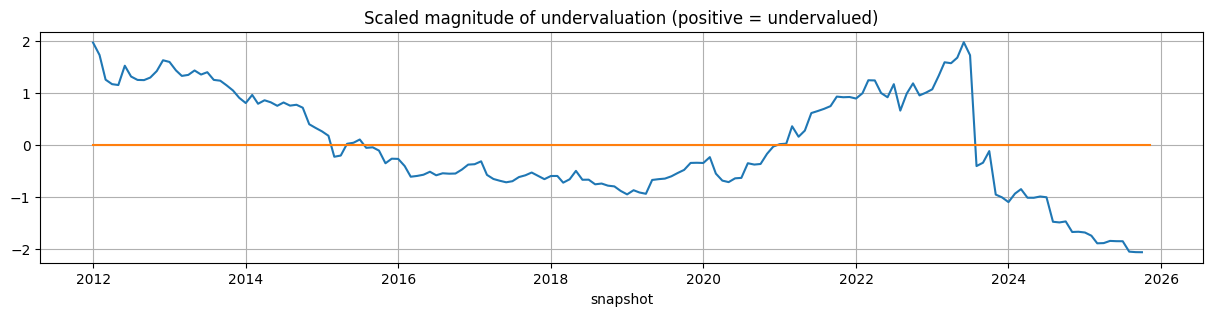

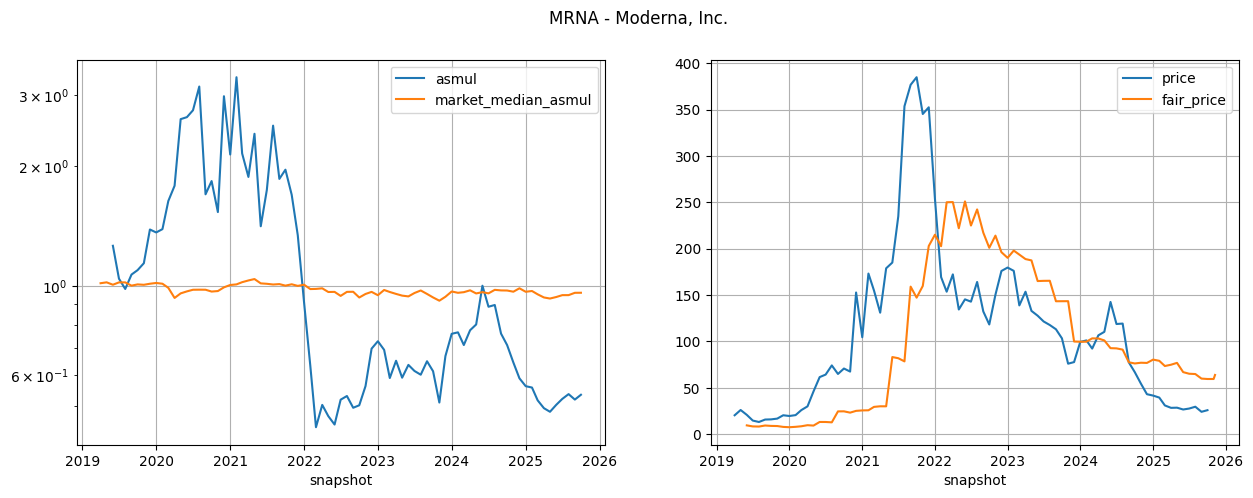

Moderna, Inc. stock pricing model:
MRNA fair_price = 12.3208 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0563


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001682852,2025-03-31,MRNA,12.704000,2.638000,-3.052000,0.577845,0.760166,5.255567,64.809209
2025-09-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.616282,0.760166,4.856483,59.892167
2025-10-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.629158,0.760166,4.821755,59.464293
2025-11-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.629158,0.760166,4.821755,59.464293
2025-11-08,0001682852,2025-09-30,MRNA,12.135000,2.805000,-1.978000,0.629158,0.760166,5.175141,63.818292


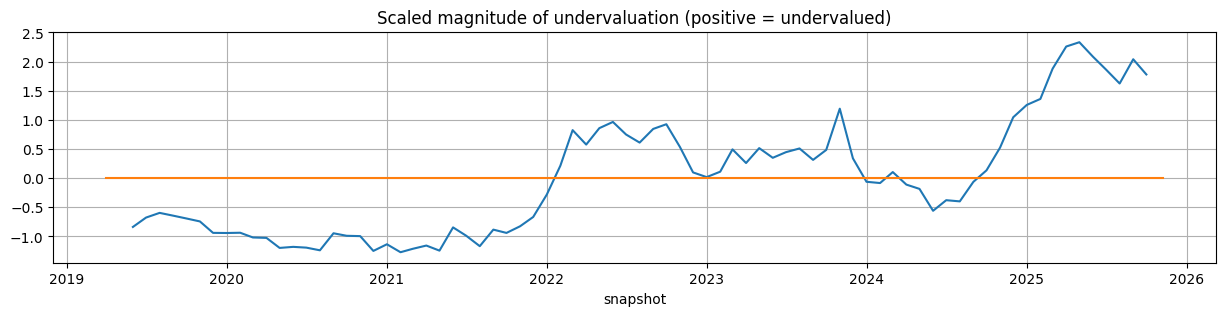

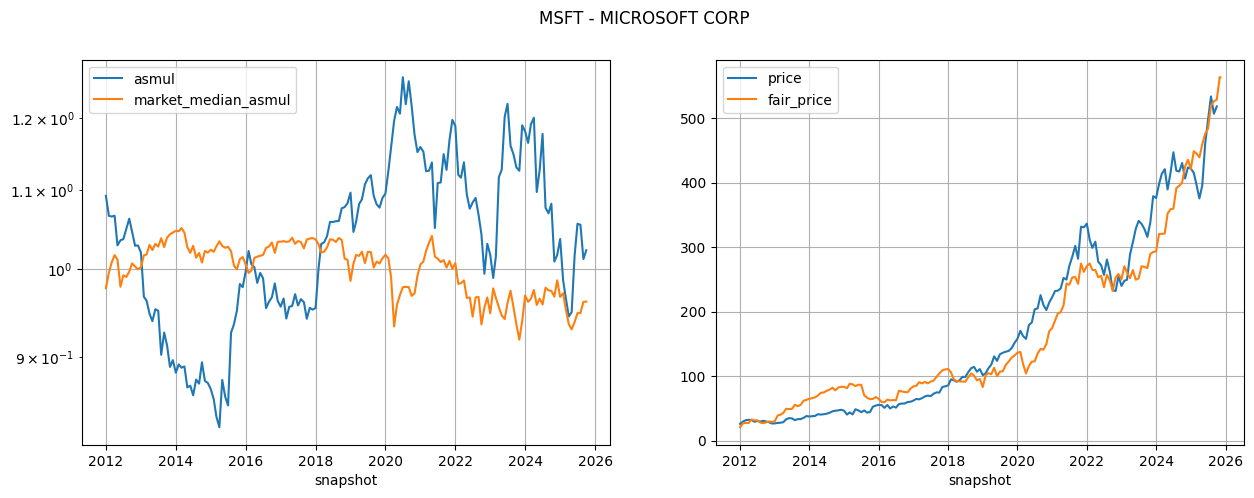

MICROSOFT CORP stock pricing model:
MSFT fair_price = 1.2869 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -53.3997


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.577845,1.037038,445.086240,519.393811
2025-09-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.616282,1.037038,450.319859,526.129097
2025-10-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.629158,1.037038,452.073142,528.385445
2025-11-01,0000789019,2025-09-30,MSFT,636.351000,273.275000,147.039000,0.629158,1.037038,479.156034,563.239149
2025-11-08,0000789019,2025-09-30,MSFT,636.351000,273.275000,147.039000,0.629158,1.037038,479.156034,563.239149


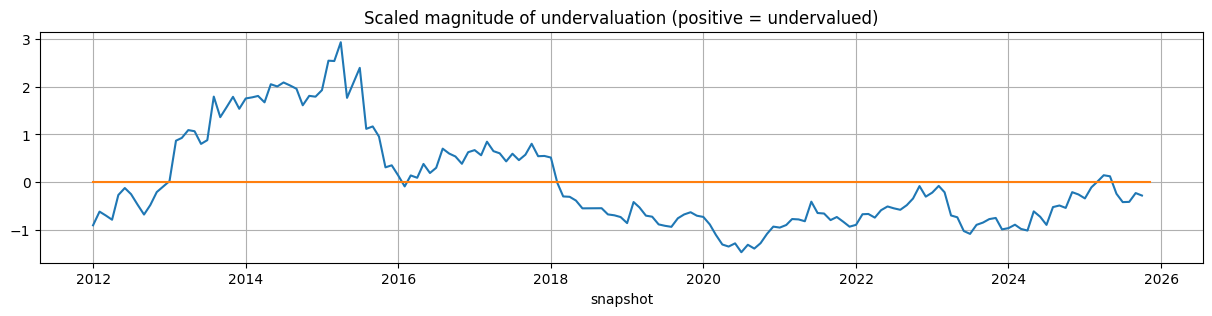

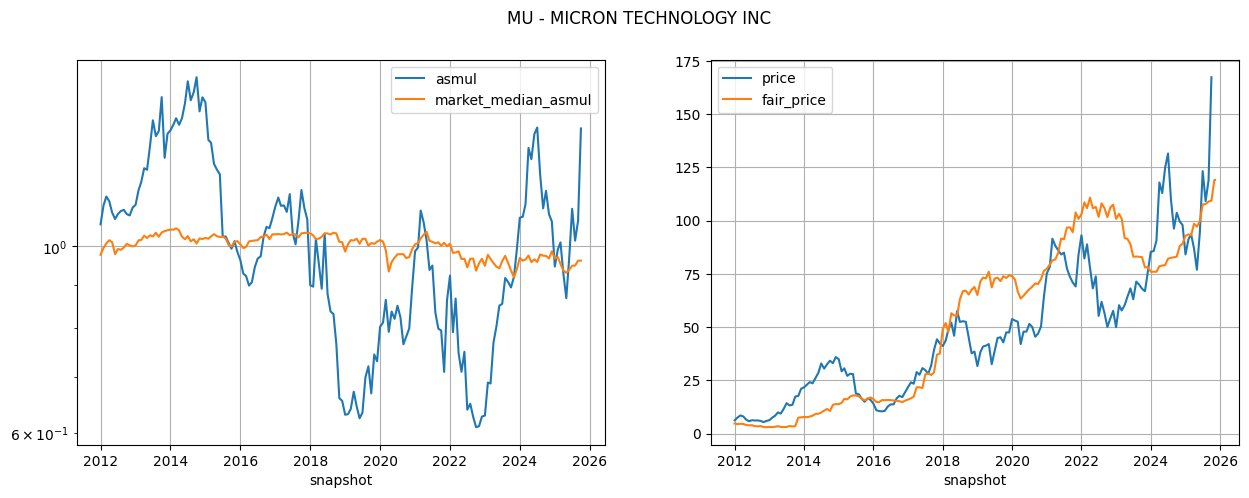

MICRON TECHNOLOGY INC stock pricing model:
MU fair_price = 1.9788 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -11.1823


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.577845,1.007766,60.140087,107.825753
2025-09-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.616282,1.007766,60.724325,108.981871
2025-10-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.629158,1.007766,60.920048,109.369175
2025-11-01,0000723125,2025-08-28,MU,82.798000,28.633000,17.525000,0.629158,1.007766,65.834019,119.093178
2025-11-08,0000723125,2025-08-28,MU,82.798000,28.633000,17.525000,0.629158,1.007766,65.834019,119.093178


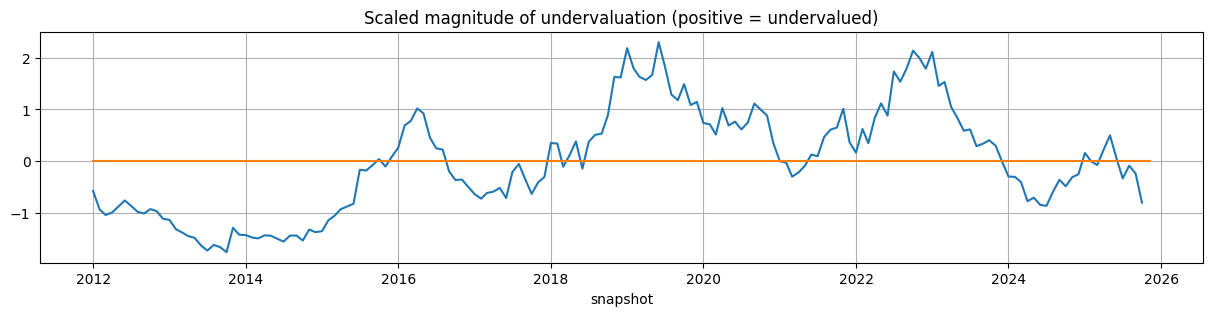

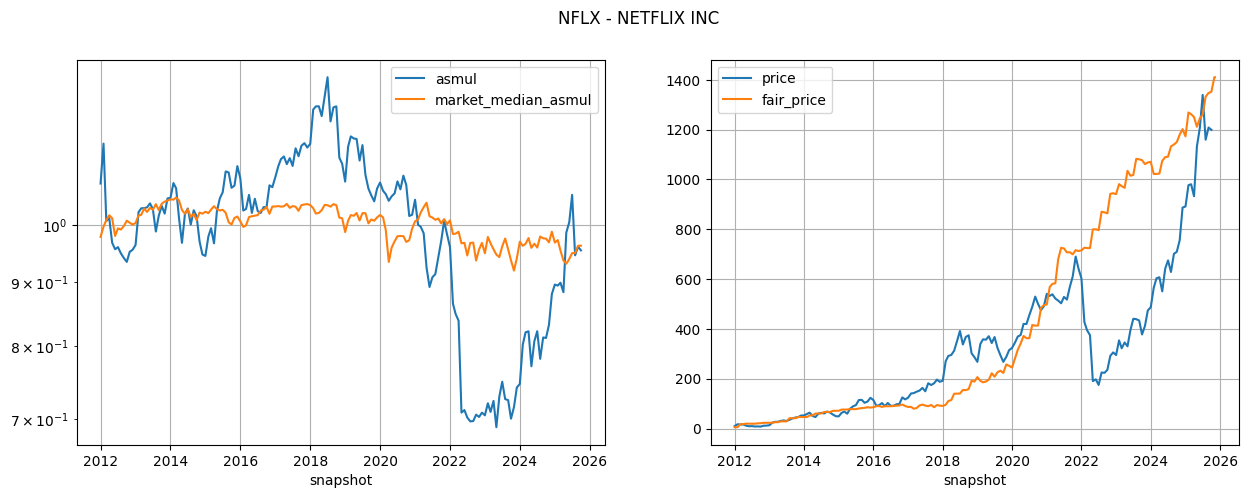

NETFLIX INC stock pricing model:
NFLX fair_price = 42.8722 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -10.0388


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.577845,1.020920,31.304050,1332.035170
2025-09-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.616282,1.020920,31.652688,1346.982067
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.629158,1.020920,31.769484,1351.989338
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,0.629158,1.020920,33.127153,1410.195619
2025-11-08,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,0.629158,1.020920,33.127153,1410.195619


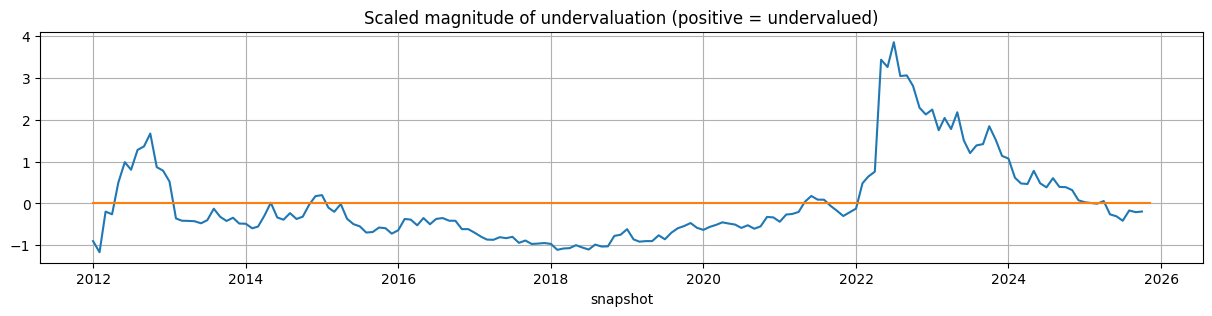

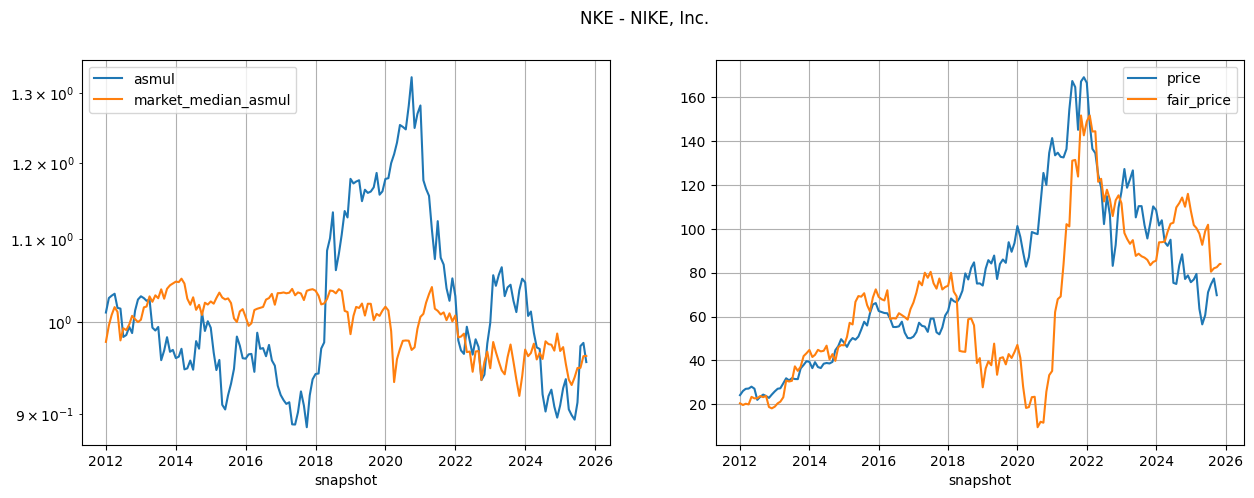

NIKE, Inc. stock pricing model:
NKE fair_price = 10.8605 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -81.3092


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.577845,0.987545,14.894263,80.449727
2025-09-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.616282,0.987545,15.036402,81.993426
2025-10-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.629158,0.987545,15.084019,82.510571
2025-11-01,0000320187,2025-08-31,NKE,37.334000,23.866000,3.526000,0.629158,0.987545,15.221400,84.002595
2025-11-08,0000320187,2025-08-31,NKE,37.334000,23.866000,3.526000,0.629158,0.987545,15.221400,84.002595


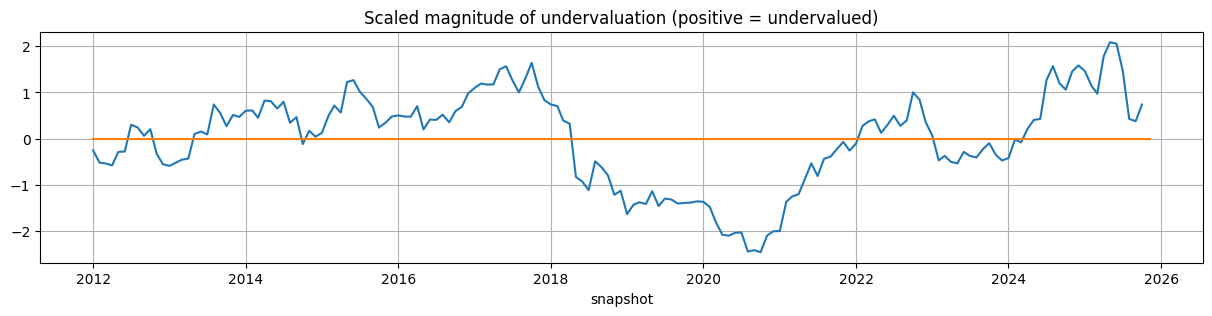

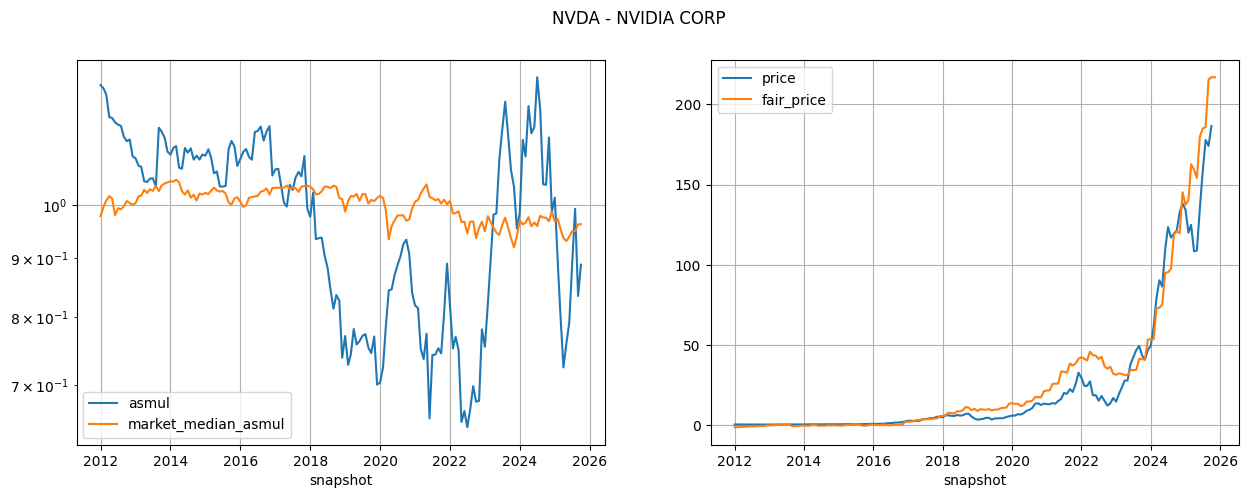

NVIDIA CORP stock pricing model:
NVDA fair_price = 1.4583 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -7.1281


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001045810,2025-04-27,NVDA,125.254000,41.411000,76.158000,0.577845,1.036238,132.389435,185.938962
2025-09-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.616282,1.036238,152.706353,215.567666
2025-10-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.629158,1.036238,153.698290,217.014235
2025-11-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.629158,1.036238,153.698290,217.014235
2025-11-08,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.629158,1.036238,153.698290,217.014235


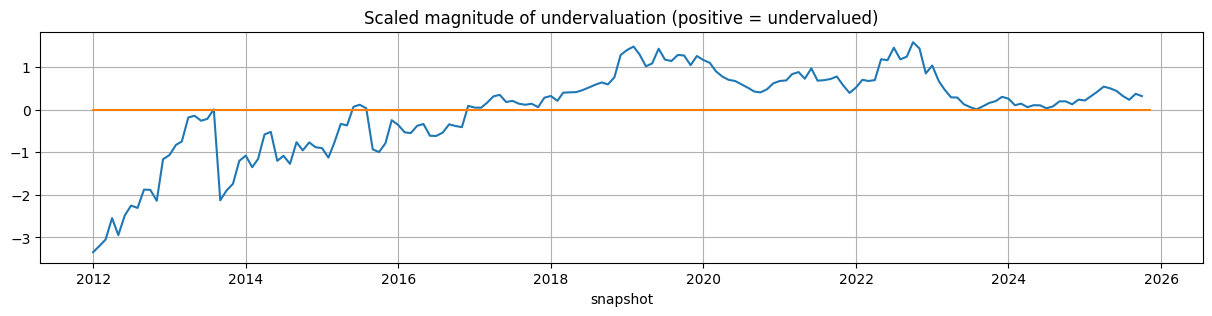

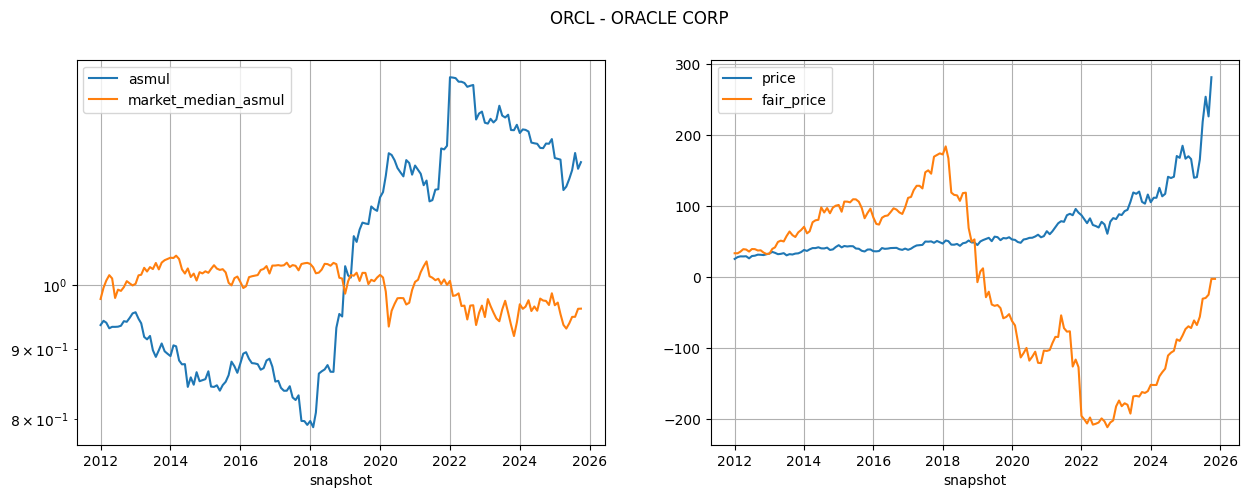

ORACLE CORP stock pricing model:
ORCL fair_price = 5.7401 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -172.5069


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001341439,2025-05-31,ORCL,168.361000,147.910000,20.821000,0.577845,0.955275,24.952358,-29.278913
2025-09-01,0001341439,2025-05-31,ORCL,168.361000,147.910000,20.821000,0.616282,0.955275,25.752649,-24.685196
2025-10-01,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.629158,0.955275,29.631703,-2.419193
2025-11-01,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.629158,0.955275,29.631703,-2.419193
2025-11-08,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.629158,0.955275,29.631703,-2.419193


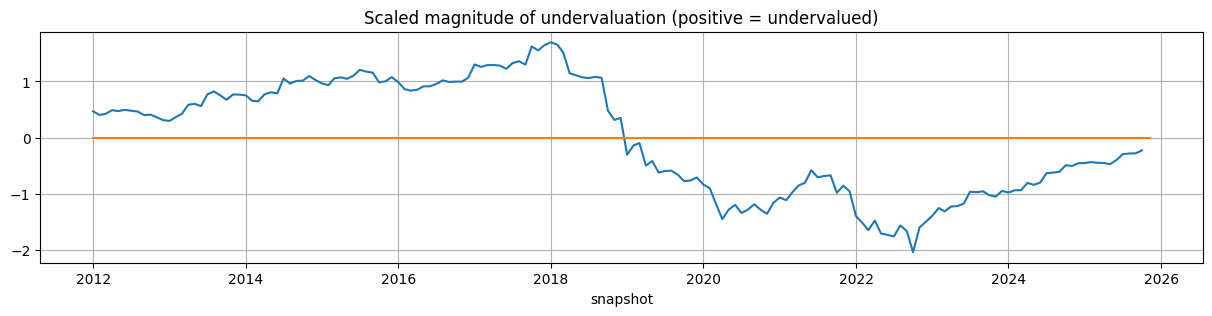

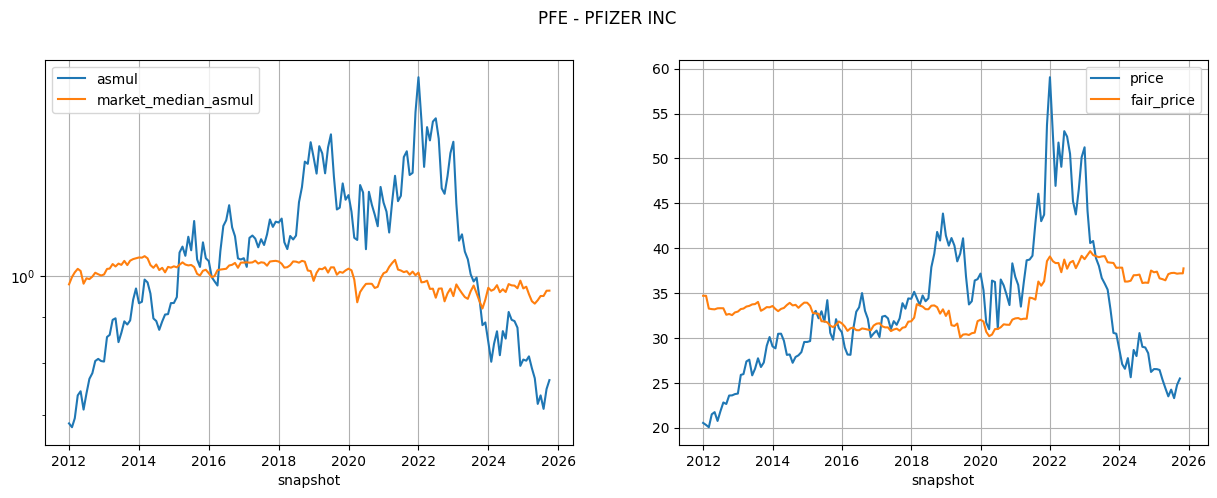

PFIZER INC stock pricing model:
PFE fair_price = 0.1875 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 16.1359


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000078003,2025-03-30,PFE,208.028000,117.690000,13.989000,0.577845,1.068360,112.642190,37.252760
2025-09-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.616282,1.068360,112.143664,37.159302
2025-10-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.629158,1.068360,112.339231,37.195965
2025-11-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.629158,1.068360,112.339231,37.195965
2025-11-08,0000078003,2025-09-28,PFE,208.731000,115.930000,13.077000,0.629158,1.068360,115.297274,37.750505


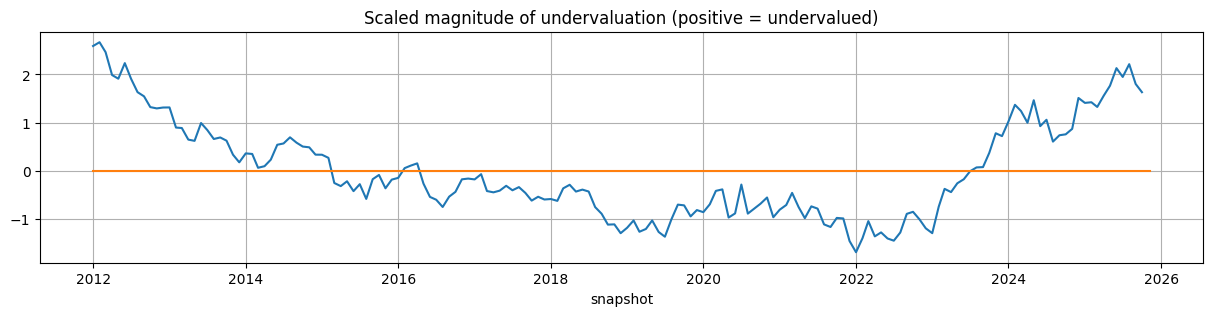

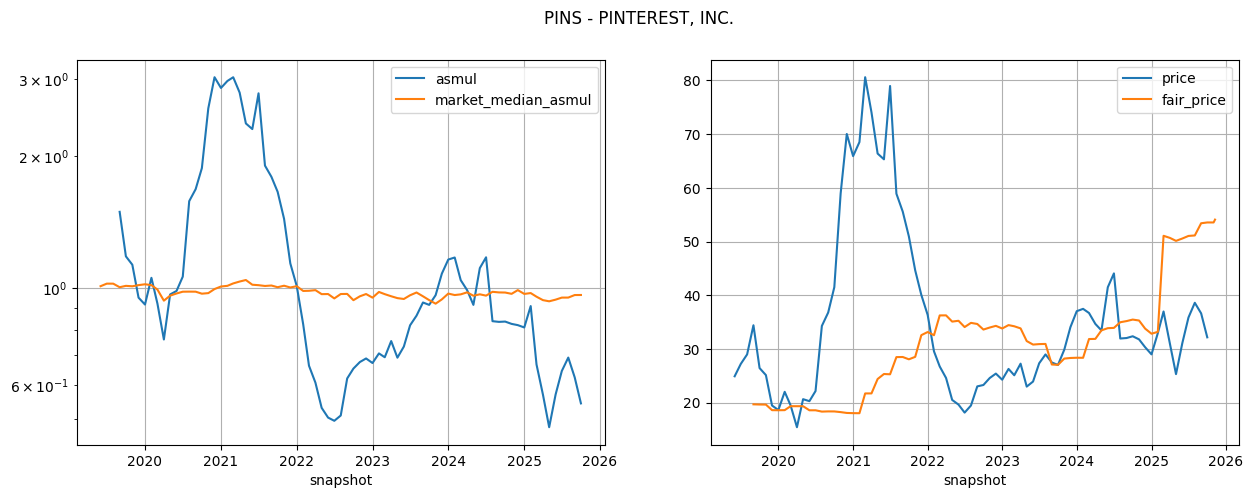

PINTEREST, INC. stock pricing model:
PINS fair_price = 10.6714 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.0463


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001506293,2025-03-31,PINS,5.282696,0.594227,0.972154,0.577845,0.913949,4.795640,51.130133
2025-09-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.616282,0.913949,5.008548,53.402170
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.629158,0.913949,5.022370,53.549669
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.629158,0.913949,5.022370,53.549669
2025-11-08,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,0.629158,0.913949,5.072033,54.079641


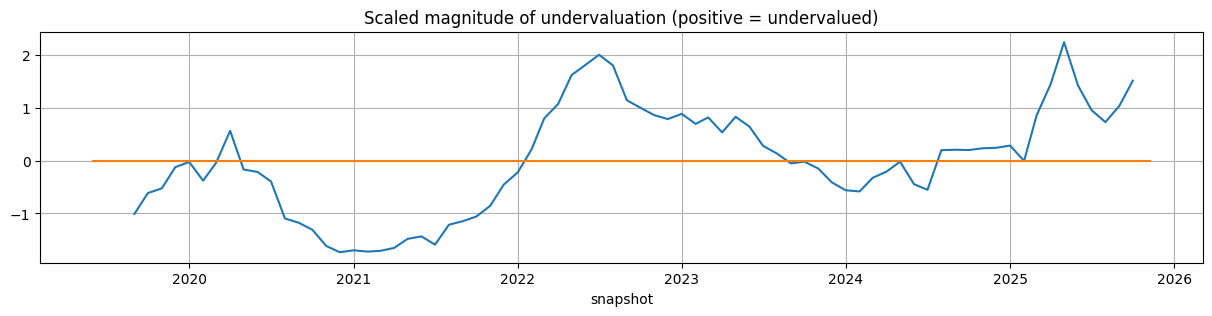

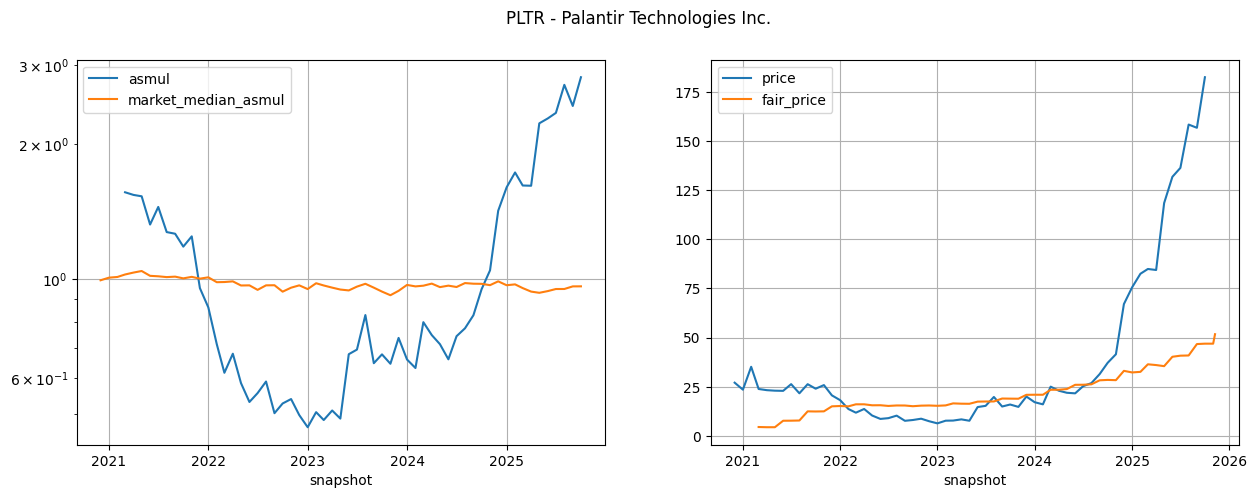

Palantir Technologies Inc. stock pricing model:
PLTR fair_price = 8.9394 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.1038


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001321655,2025-03-31,PLTR,6.736917,1.312762,1.334549,0.577845,0.761837,4.590837,40.935574
2025-09-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.616282,0.761837,5.240599,46.744075
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.629158,0.761837,5.262871,46.943167
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.629158,0.761837,5.262871,46.943167
2025-11-08,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.629158,0.761837,5.801514,51.758327


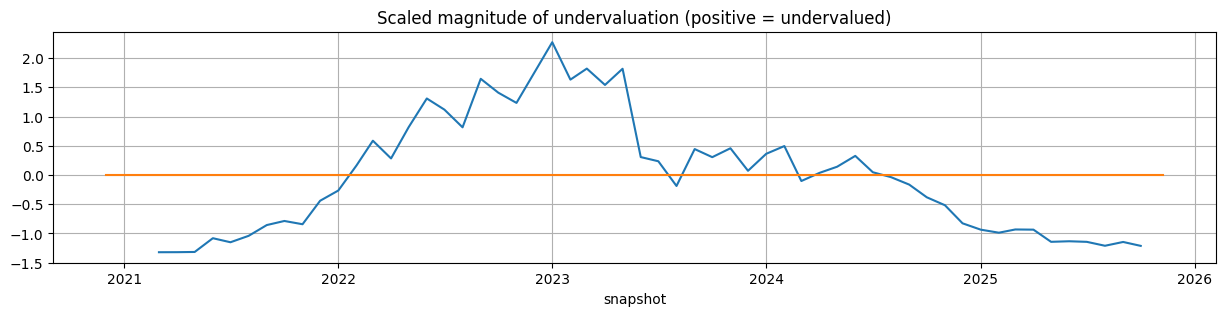

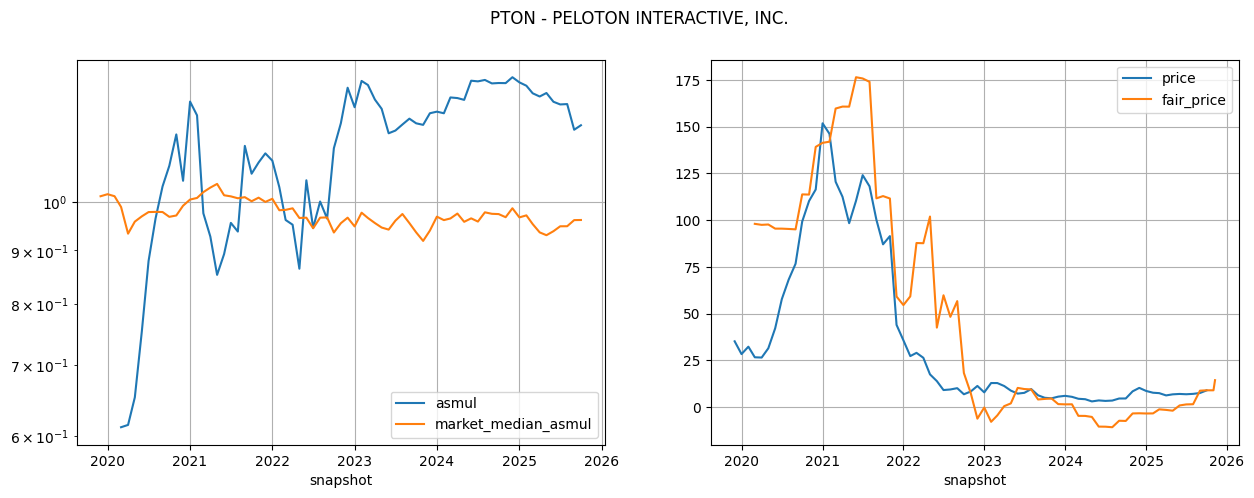

PELOTON INTERACTIVE, INC. stock pricing model:
PTON fair_price = 48.1646 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0682


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001639825,2025-03-31,PTON,2.064800,2.556100,0.248600,0.577845,1.183839,0.031944,1.606717
2025-09-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.616282,1.183839,0.182136,8.840640
2025-10-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.629158,1.183839,0.186423,9.047163
2025-11-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.629158,1.183839,0.186423,9.047163
2025-11-08,0001639825,2025-09-30,PTON,2.170100,2.517100,0.392400,0.629158,1.183839,0.298831,14.461245


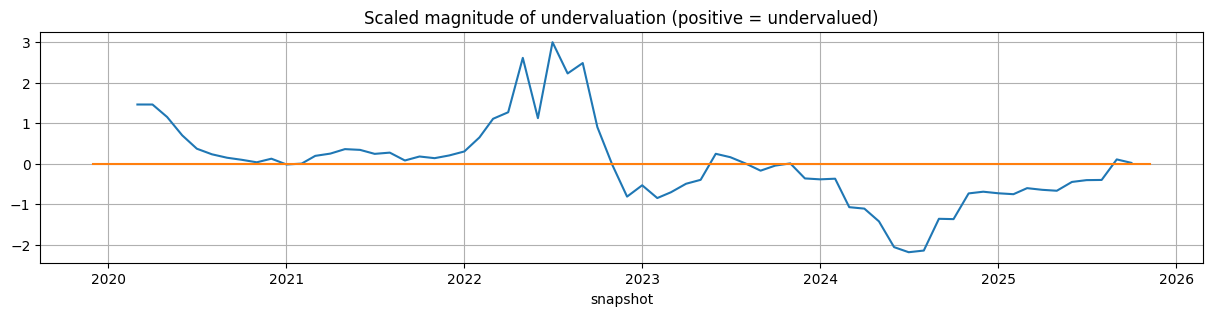

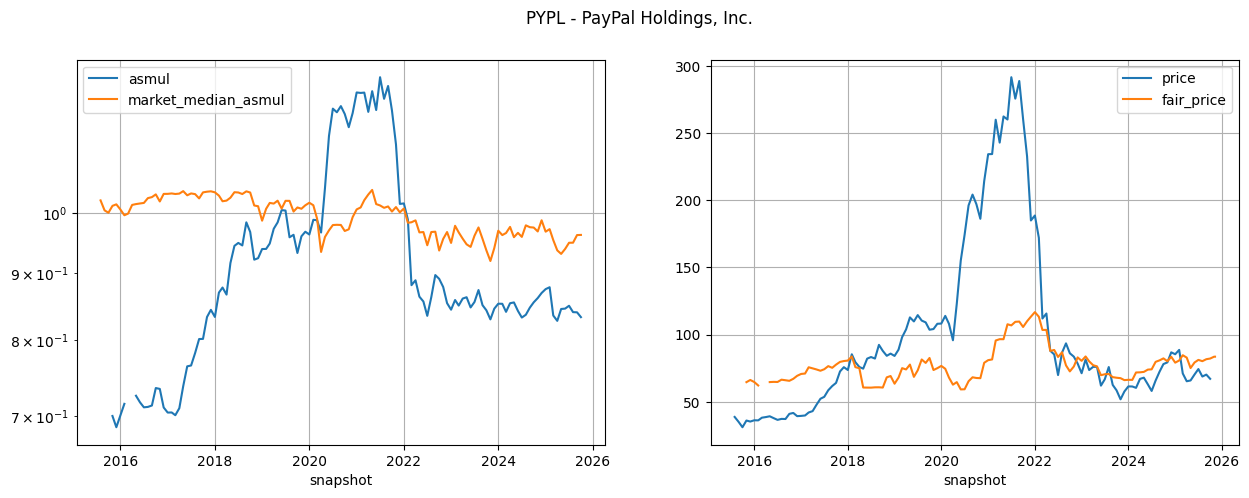

PayPal Holdings, Inc. stock pricing model:
PYPL fair_price = 6.2818 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.0192


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.577845,0.862898,12.768636,80.190795
2025-09-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.616282,0.862898,13.001793,81.655441
2025-10-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.629158,0.862898,13.079902,82.146103
2025-11-01,0001633917,2025-09-30,PYPL,79.801000,59.603000,6.426000,0.629158,0.862898,13.300108,83.529395
2025-11-08,0001633917,2025-09-30,PYPL,79.801000,59.603000,6.426000,0.629158,0.862898,13.300108,83.529395


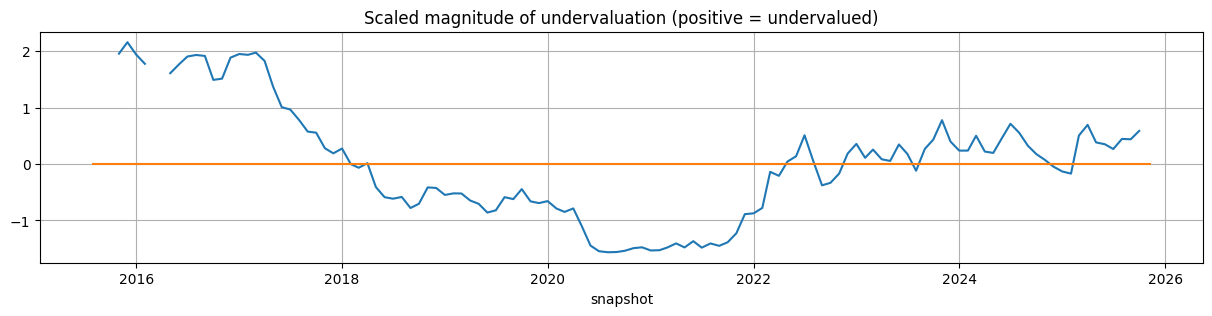

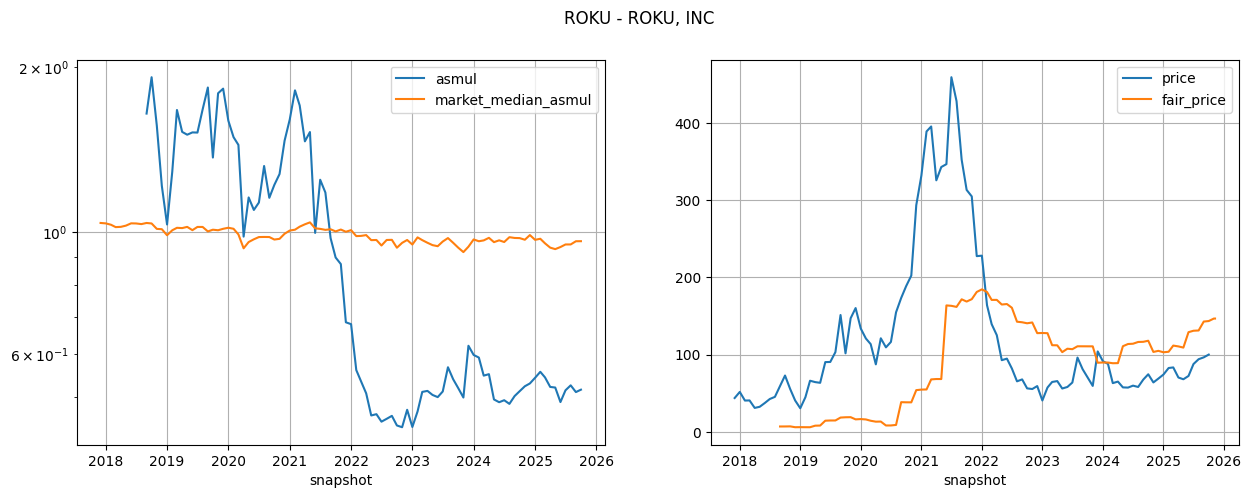

ROKU, INC stock pricing model:
ROKU fair_price = 130.4424 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0422


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001428439,2025-03-31,ROKU,4.179874,1.654165,0.310094,0.577845,0.593710,1.006654,131.352527
2025-09-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.616282,0.593710,1.095143,142.895274
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.629158,0.593710,1.100248,143.561117
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.629158,0.593710,1.125006,146.790677
2025-11-08,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.629158,0.593710,1.125006,146.790677


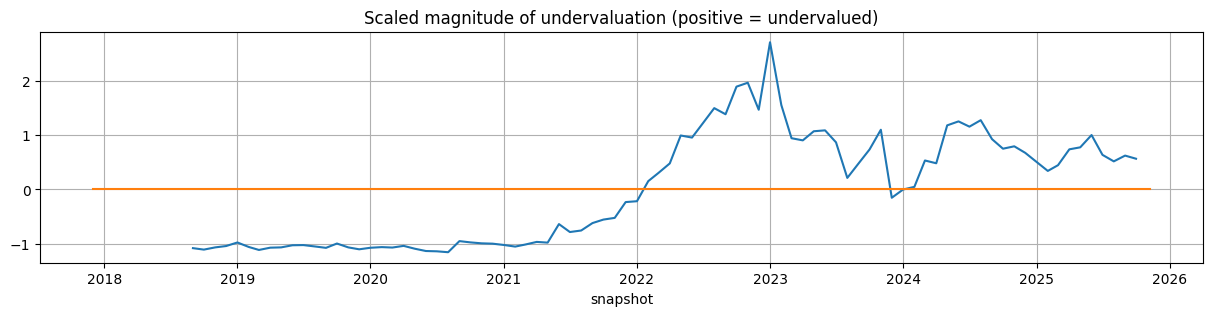

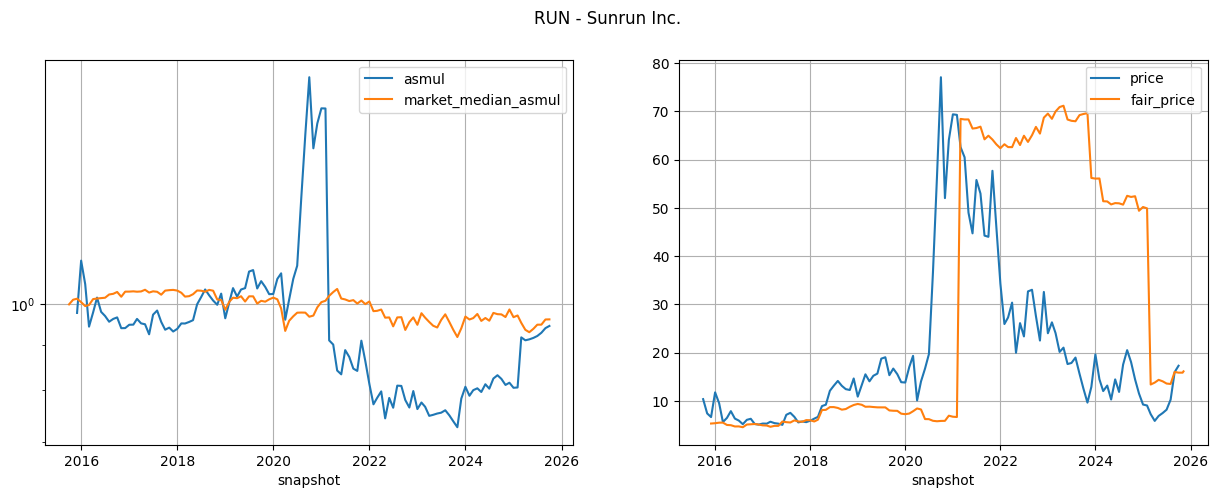

Sunrun Inc. stock pricing model:
RUN fair_price = 13.756 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0227


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001469367,2025-03-31,RUN,20.377855,17.762453,-0.727266,0.577845,0.940403,0.980702,13.513210
2025-09-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.616282,0.940403,1.161442,15.999467
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.629158,0.940403,1.150994,15.855749
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.629158,0.940403,1.150994,15.855749
2025-11-08,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.629158,0.940403,1.170639,16.125988


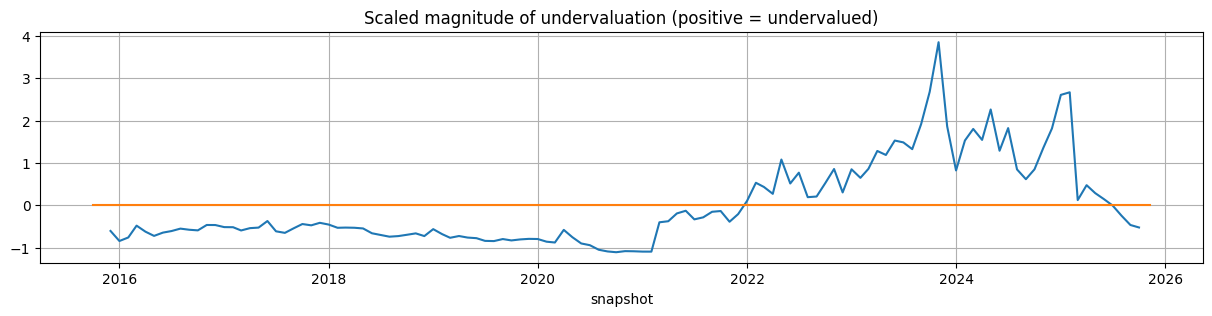

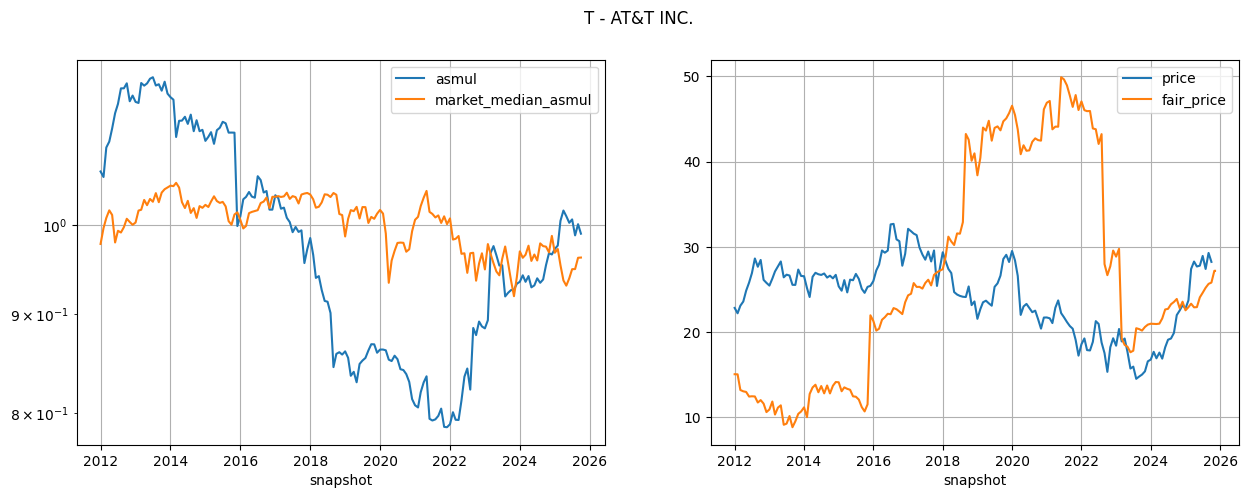

AT&T INC. stock pricing model:
T fair_price = 0.29 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -13.2467


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.577845,0.969249,132.583392,25.204808
2025-09-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.616282,0.969249,134.157106,25.661212
2025-10-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.629158,0.969249,134.684307,25.814109
2025-11-01,0000732717,2025-09-30,T,423.213000,296.458000,40.860000,0.629158,0.969249,139.448115,27.195695
2025-11-08,0000732717,2025-09-30,T,423.213000,296.458000,40.860000,0.629158,0.969249,139.448115,27.195695


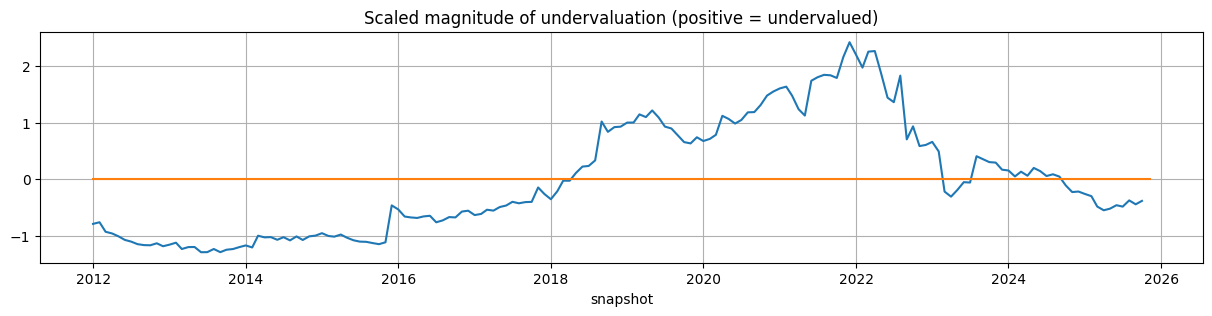

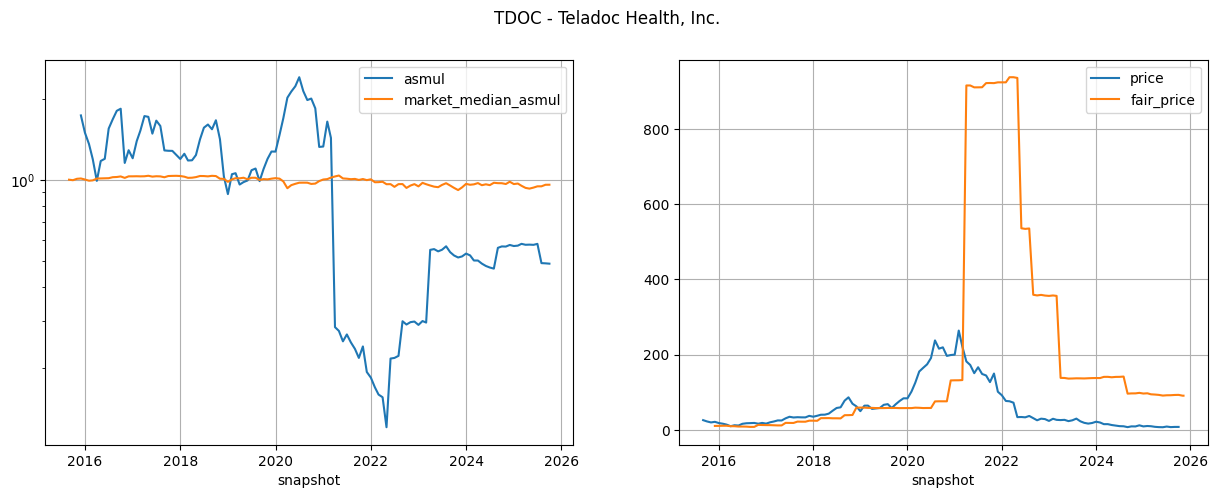

Teladoc Health, Inc. stock pricing model:
TDOC fair_price = 58.1571 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0661


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.577845,0.994052,1.580261,91.969463
2025-09-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.616282,0.994052,1.591924,92.647736
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.629158,0.994052,1.595831,92.874960
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.629158,0.994052,1.559034,90.734965
2025-11-08,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.629158,0.994052,1.559034,90.734965


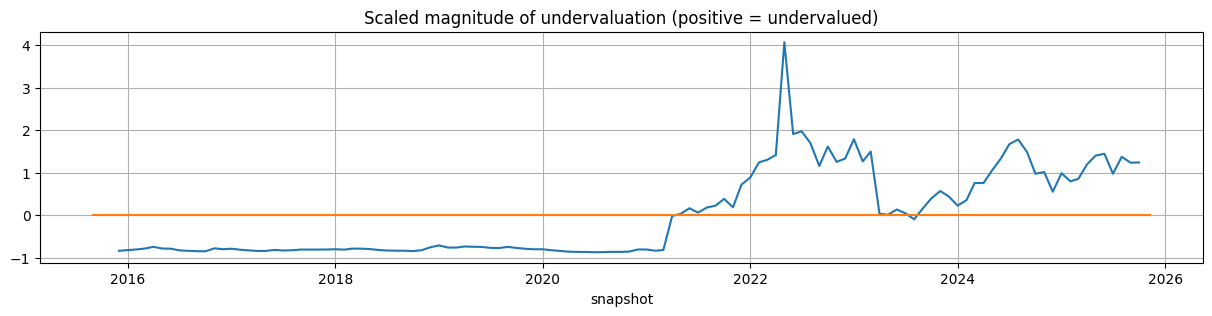

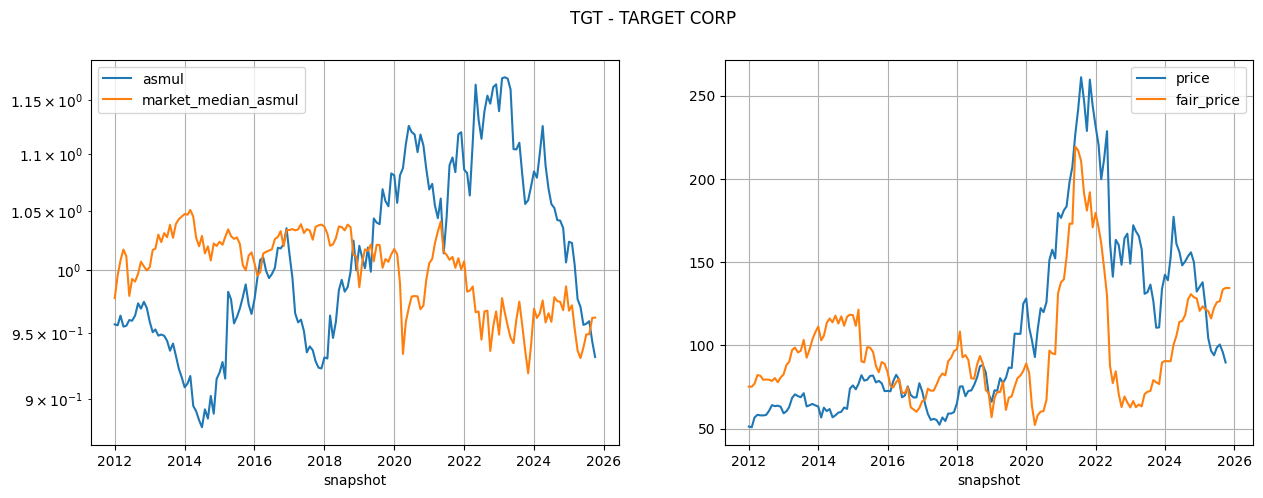

TARGET CORP stock pricing model:
TGT fair_price = 11.1558 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -82.9429


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000027419,2025-05-03,TGT,56.185000,41.238000,6.541000,0.577845,1.000858,18.774896,126.505498
2025-09-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.616282,1.000858,19.405216,133.537206
2025-10-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.629158,1.000858,19.487445,134.454533
2025-11-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.629158,1.000858,19.487445,134.454533
2025-11-08,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.629158,1.000858,19.487445,134.454533


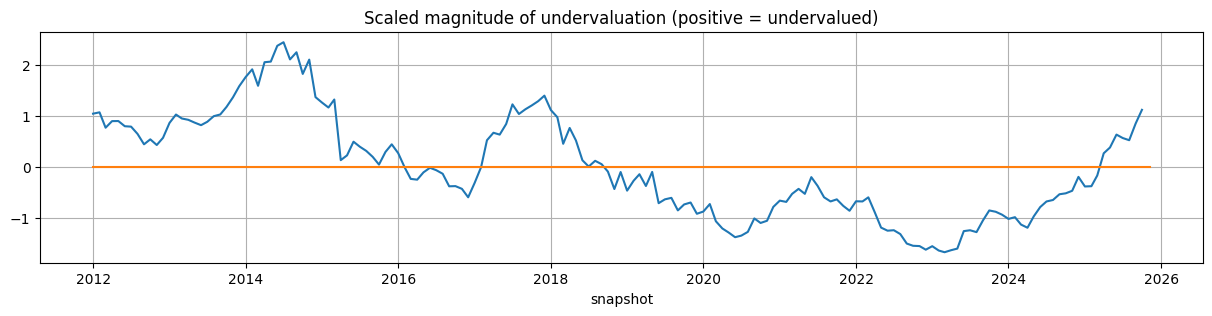

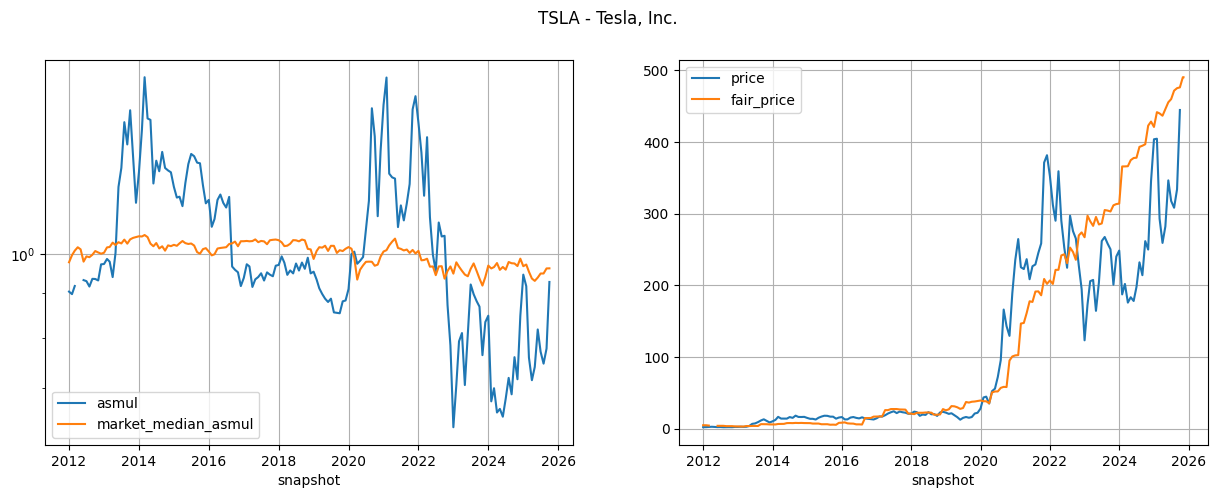

Tesla, Inc. stock pricing model:
TSLA fair_price = 5.6667 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 2.8209


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.577845,0.971429,82.750440,471.739718
2025-09-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.616282,0.971429,83.356395,475.173459
2025-10-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.629158,0.971429,83.559392,476.323776
2025-11-01,0001318605,2025-09-30,TSLA,133.735000,53.765000,15.748000,0.629158,0.971429,86.057041,490.477113
2025-11-08,0001318605,2025-09-30,TSLA,133.735000,53.765000,15.748000,0.629158,0.971429,86.057041,490.477113


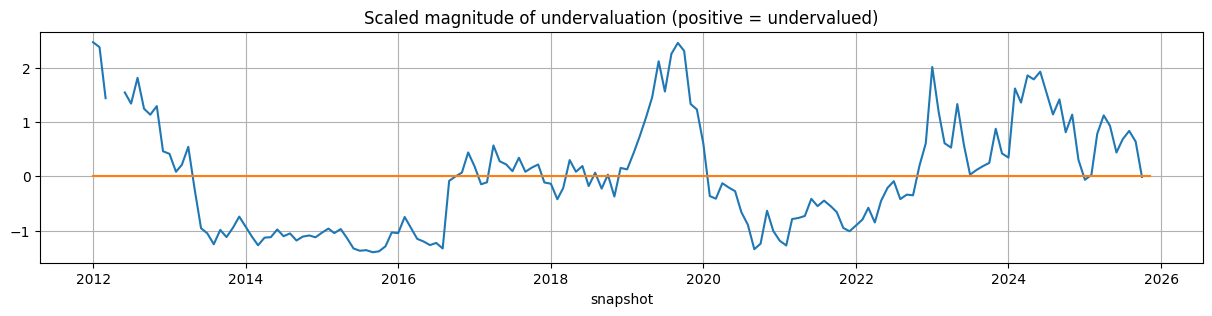

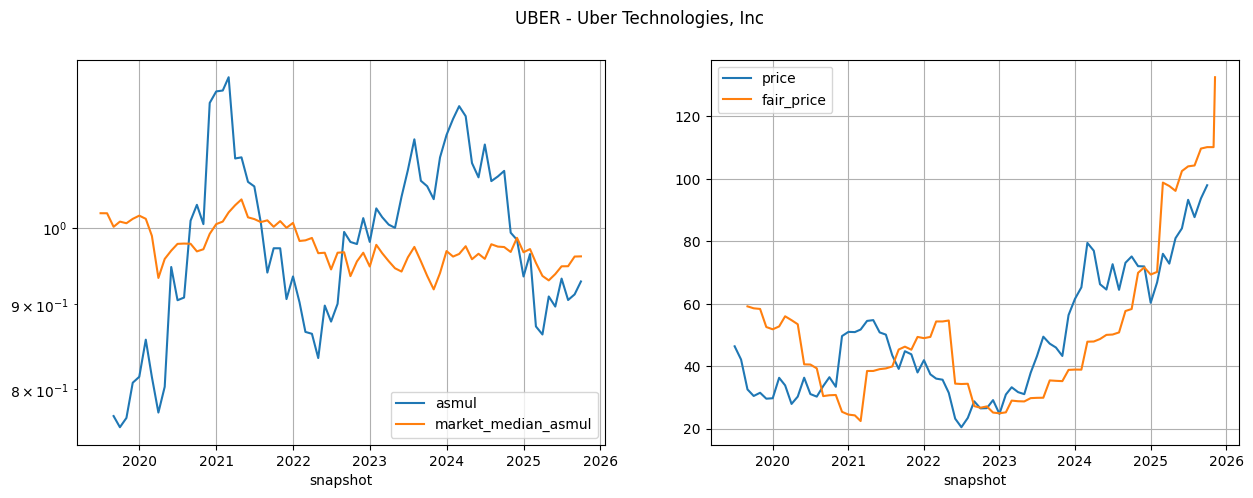

Uber Technologies, Inc stock pricing model:
UBER fair_price = 4.0558 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0006


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001543151,2025-03-31,UBER,52.822000,30.847000,8.045000,0.577845,0.982809,25.715711,104.299033
2025-09-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.616282,0.982809,27.052125,109.719294
2025-10-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.629158,0.982809,27.165296,110.178297
2025-11-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.629158,0.982809,27.165296,110.178297
2025-11-08,0001543151,2025-09-30,UBER,63.344000,35.210000,8.966000,0.629158,0.982809,32.686099,132.569705


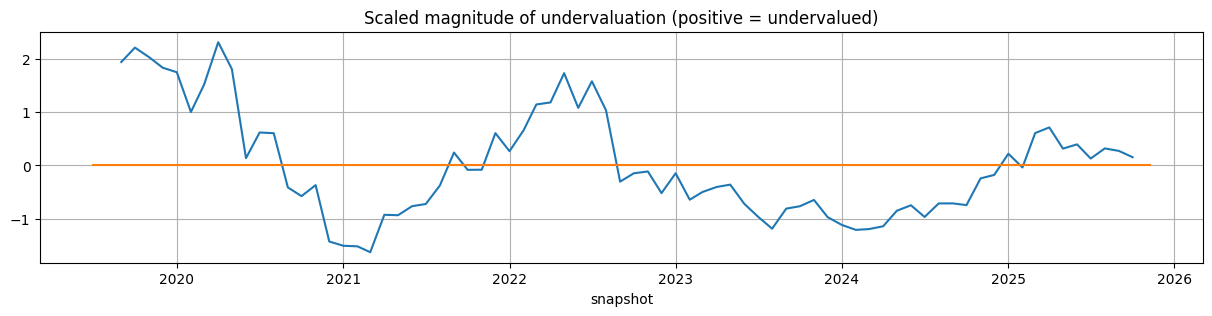

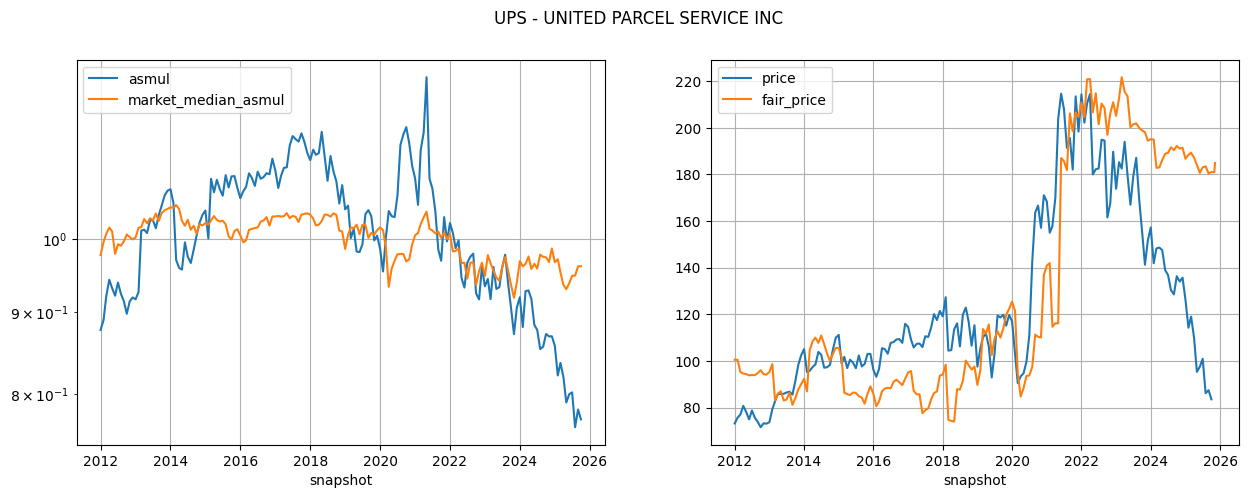

UNITED PARCEL SERVICE INC stock pricing model:
UPS fair_price = 5.6337 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 59.9181


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001090727,2025-03-31,UPS,68.466000,52.806000,9.124000,0.577845,1.014597,21.931637,183.475499
2025-09-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.616282,1.014597,21.394414,180.448919
2025-10-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.629158,1.014597,21.490717,180.991466
2025-11-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.629158,1.014597,21.490717,180.991466
2025-11-08,0001090727,2025-09-30,UPS,71.392000,55.569000,8.463000,0.629158,1.014597,22.189654,184.929106


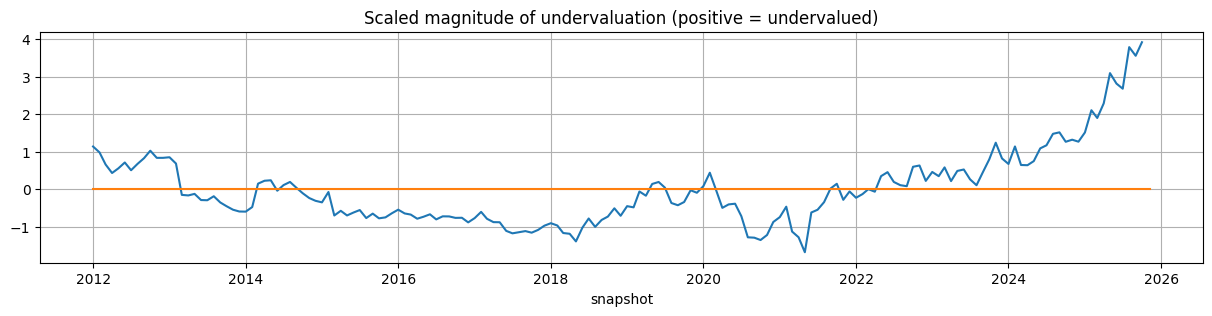

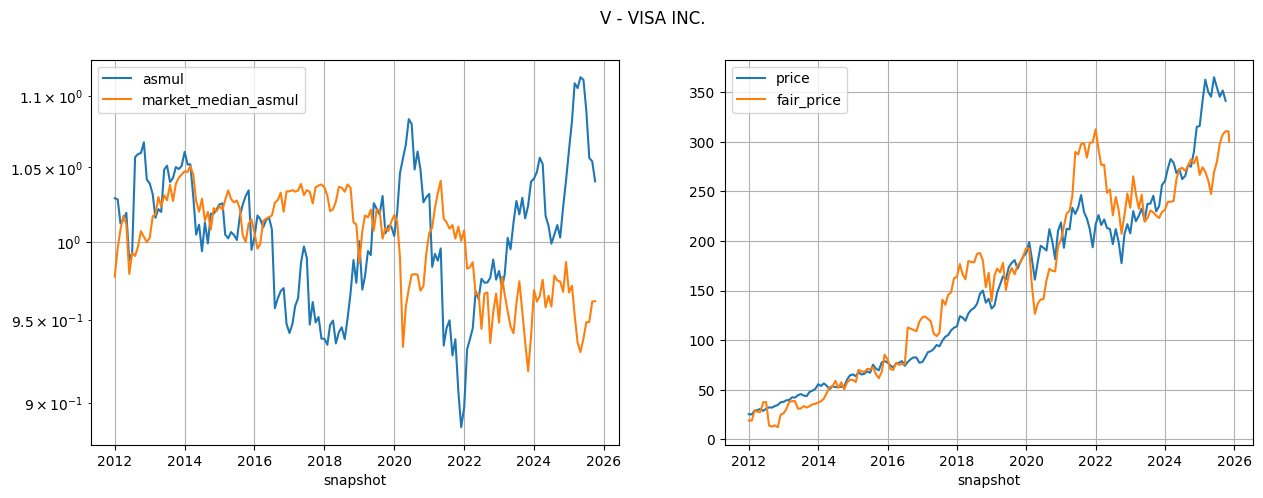

VISA INC. stock pricing model:
V fair_price = 10.2287 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -246.912


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.577845,1.010739,53.308848,298.370503
2025-09-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.616282,1.010739,54.211534,307.603848
2025-10-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.629158,1.010739,54.513938,310.697055
2025-11-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.629158,1.010739,54.513938,310.697055
2025-11-08,0001403161,2025-09-30,V,99.627000,61.718000,23.059000,0.629158,1.010739,53.486653,300.189222


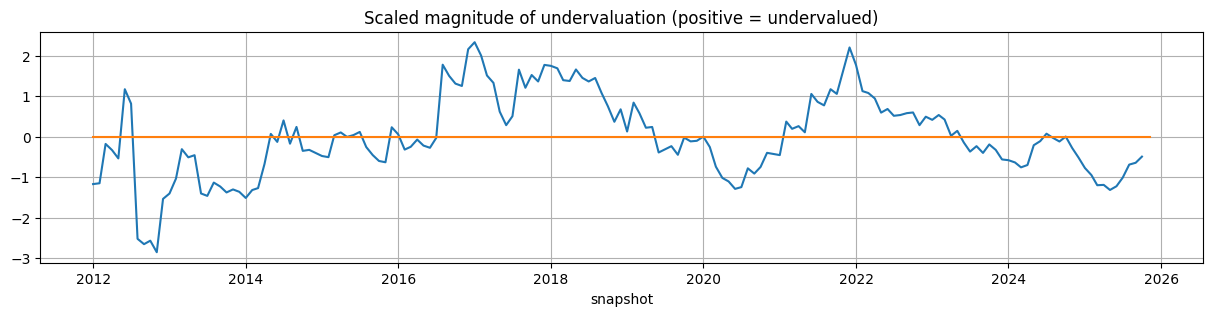

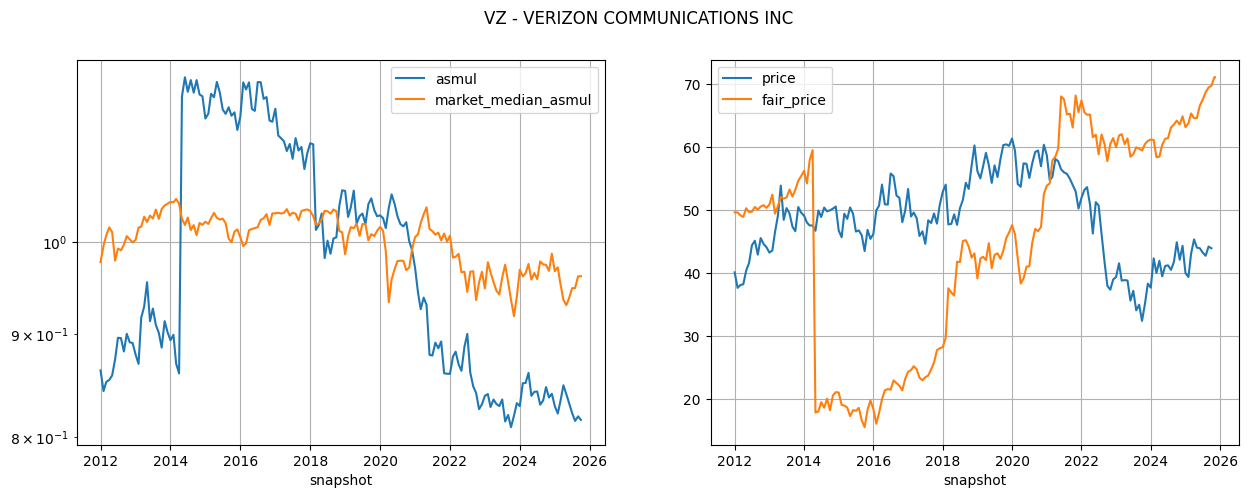

VERIZON COMMUNICATIONS INC stock pricing model:
VZ fair_price = 0.5393 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 13.0575


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.577845,0.941189,103.257632,68.747216
2025-09-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.616282,0.941189,104.683634,69.516298
2025-10-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.629158,0.941189,105.161350,69.773943
2025-11-01,0000732712,2025-09-30,VZ,388.331000,281.986000,38.455000,0.629158,0.941189,107.701099,71.143700
2025-11-08,0000732712,2025-09-30,VZ,388.331000,281.986000,38.455000,0.629158,0.941189,107.701099,71.143700


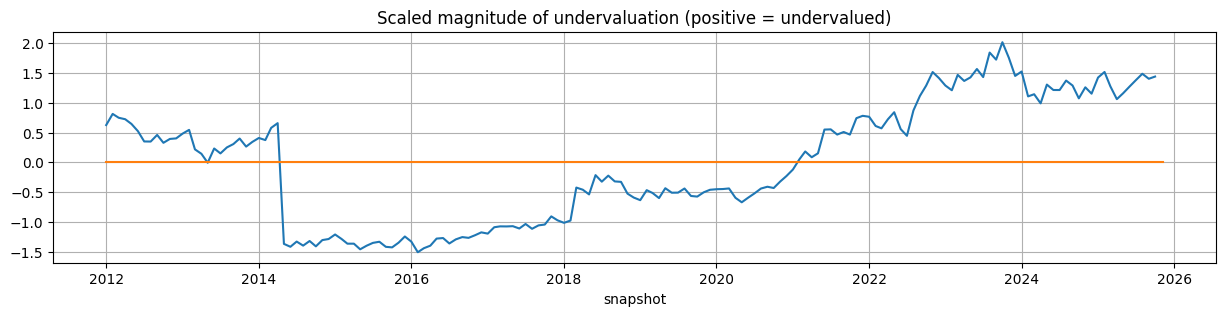

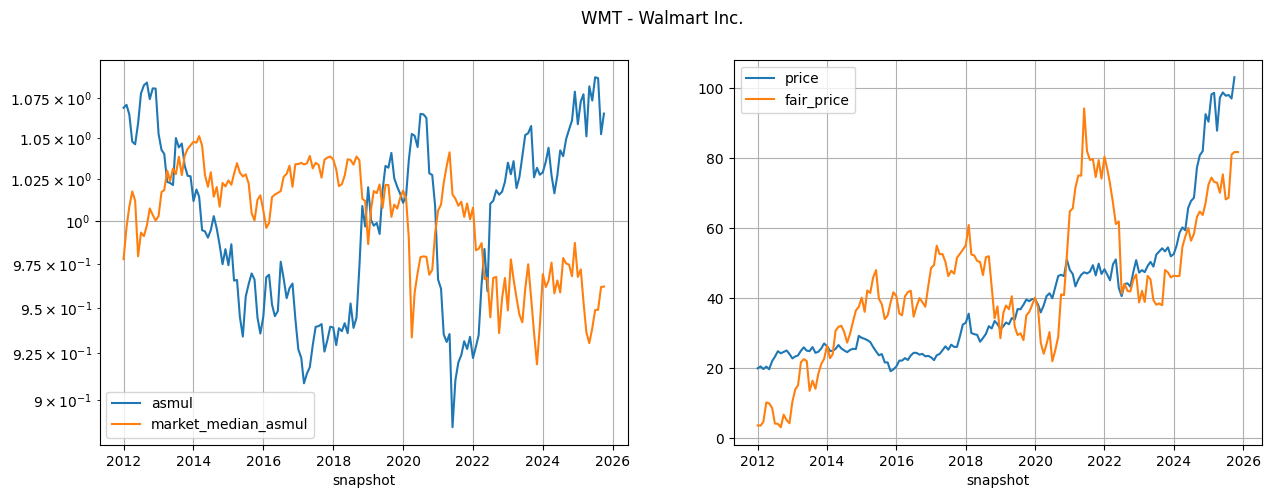

Walmart Inc. stock pricing model:
WMT fair_price = 1.4709 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -91.0451


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000104169,2025-04-30,WMT,262.372000,178.579000,37.605000,0.577845,1.011590,108.563635,68.639553
2025-09-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.616282,1.011590,116.937515,80.956573
2025-10-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.629158,1.011590,117.432460,81.684580
2025-11-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.629158,1.011590,117.432460,81.684580
2025-11-08,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.629158,1.011590,117.432460,81.684580


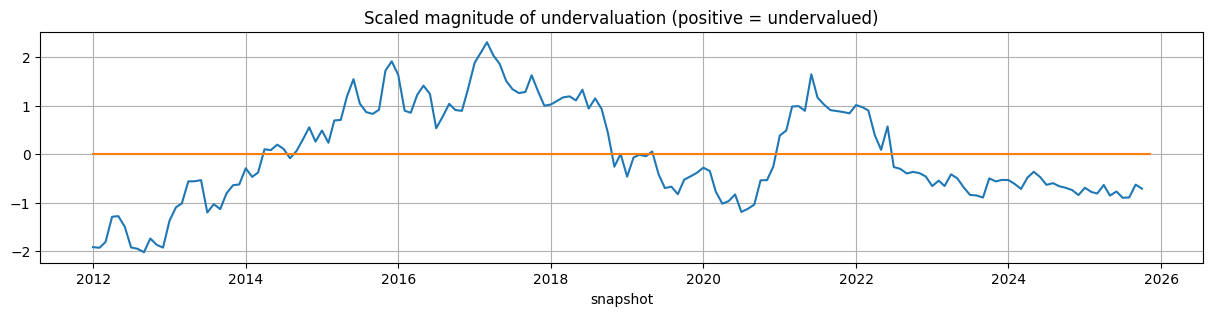

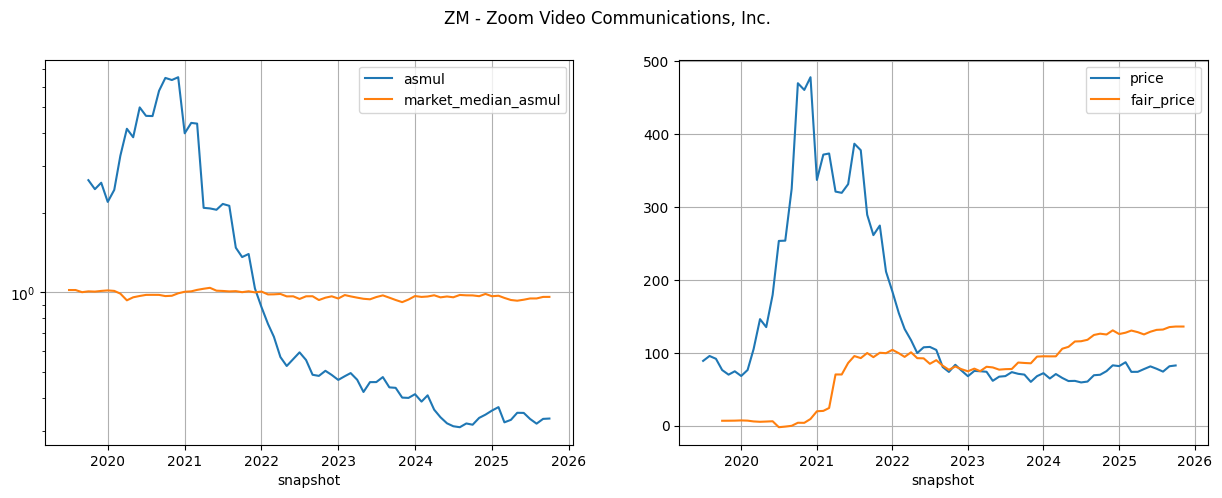

Zoom Video Communications, Inc. stock pricing model:
ZM fair_price = 29.7642 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.4741


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001585521,2025-04-30,ZM,10.951896,2.049528,1.846378,0.577845,0.495664,4.445852,131.853236
2025-09-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.616282,0.495664,4.559095,135.223815
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.629158,0.495664,4.583727,135.956981
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.629158,0.495664,4.583727,135.956981
2025-11-08,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.629158,0.495664,4.583727,135.956981


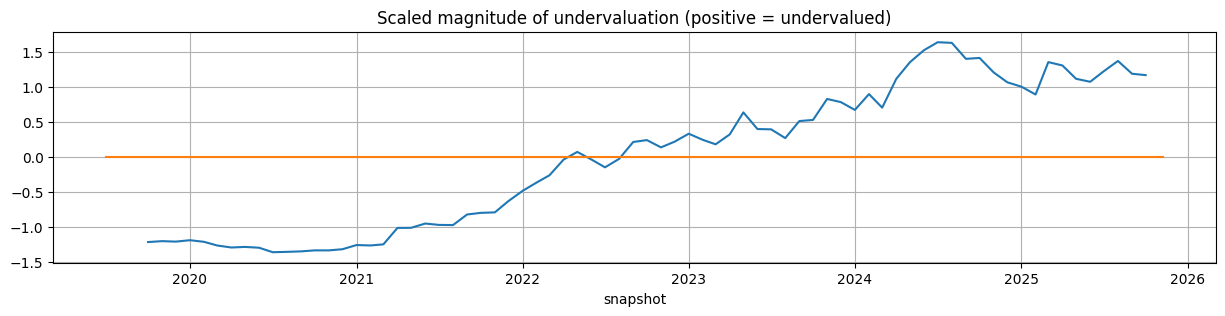

In [18]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')
    
    # Used to plot the market baseline for the asset multiplier graph
    df[market_median_asmul.name] = market_median_asmul

    # The cash multiplier is not available for the most recent snapshots, which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['cashmul'] = df['cashmul'].interpolate()

    # We calculate the fair price by using the same asset multiplier for all data points of a company.
    # The best results seem to be when we use the median
    df['fair_asmul'] = df['asmul'].quantile(0.5)

    # Now we have everything to re-compute the model
    df['fair_model'] = df['fair_asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']

    # The model values and the price correlate perfectly by design, so the simplest linear regression will yield
    # conversion between our re-calculation of the model and the fair price.
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    fair_model = df[['fair_model']].dropna()
    df['fair_price'] = 0.0
    if not fair_model.empty:
        df['fair_price'] = pd.Series(regressor.predict(fair_model.rename(columns={'fair_model':'model'})),
                                     index=fair_model.index)
    else:
        df['fair_price'] = None

    df['undervaluation'] = preprocessing.scale(df['fair_price']/df['price'])

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    ax1.set_yscale('log')
    df[['asmul',market_median_asmul.name]].plot(ax=ax1, grid=True, legend=True)
    df[['price','fair_price']].plot(ax=ax2, grid=True, legend=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print(f"{name} stock pricing model:")
    print("{} fair_price = {} * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) {} {}".format(
        ticker, regressor.coef_[0].round(4), "+" if regressor.intercept_ >= 0 else "", regressor.intercept_.round(4)
    ))
    display(df.tail(5).dropna(axis='columns'))

    df['undervaluation'].plot(figsize=(15,3),title='Scaled magnitude of undervaluation (positive = undervalued)',grid=True)
    pd.Series([0.0]*len(df.index),index=df.index).plot(grid=True)
    plt.show()

    return df.reset_index().set_index(['snapshot','cik'])

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is eazy to notice that, for example, the Verizon model (ticker VZ) has some extreme distortion. It is caused by an abrupt shift in the assets and liabilities between 2014-04-01 and 2014-05-01<br>
| snapshot  | Quarter End |  Assets    | Liabilities | Equity | NetCashOp_ttm |
|-----------|-------------|------------|-------------|--------|---------------|
|2014-04-01 | 2013-12-31  | 274.098000 | 178.682000  | 95.416 | 38.818000     |
|2014-05-01 | 2014-03-31  | 221.562000 | 207.711000  | 13.851 | 38.426000     |

Such anomalies appear for many other companies, too, and should be investigated further. They are probably caused by shifting corporate accounting practicies over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.  
The biggest advantage of the model, however, is that its results are completely explainable.


In [19]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

              price  fair_price
price      1.000000    0.790686
fair_price 0.790686    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,market_median_asmul,fair_asmul,fair_model,fair_price,undervaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032000,140.517000,29.761000,40.120000,0.863452,-0.209088,50.155074,0.977562,0.941189,67.881524,49.667906,0.624805
2012-02-01,0000732712,2011-09-30,VZ,228.032000,140.517000,29.761000,37.660000,0.843275,-0.210137,45.522821,0.996108,0.941189,67.850301,49.651067,0.812117
2012-03-01,0000732712,2011-12-31,VZ,230.461000,144.553000,29.780000,38.110000,0.852262,-0.180075,46.497592,1.008140,0.941189,66.991694,49.187997,0.747555
2012-04-01,0000732712,2011-12-31,VZ,230.461000,144.553000,29.780000,38.230000,0.854161,-0.195613,46.472414,1.017251,0.941189,66.528966,48.938435,0.722914
2012-05-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,40.380000,0.858549,-0.202602,50.668433,1.011717,0.941189,69.090489,50.319935,0.643849
2012-06-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,41.640000,0.874470,-0.238987,53.100246,0.979245,0.941189,67.973378,49.717446,0.522320
2012-07-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,44.440000,0.896377,-0.235841,58.080552,0.992934,0.941189,68.069960,49.769535,0.349829
2012-08-01,0000732712,2012-06-30,VZ,226.072000,135.644000,32.259000,45.140000,0.896051,-0.237968,59.251408,0.990886,0.941189,69.455846,50.516982,0.347946
2012-09-01,0000732712,2012-06-30,VZ,226.072000,135.644000,32.259000,42.940000,0.882437,-0.261596,55.411402,0.997242,0.941189,68.693638,50.105902,0.459196


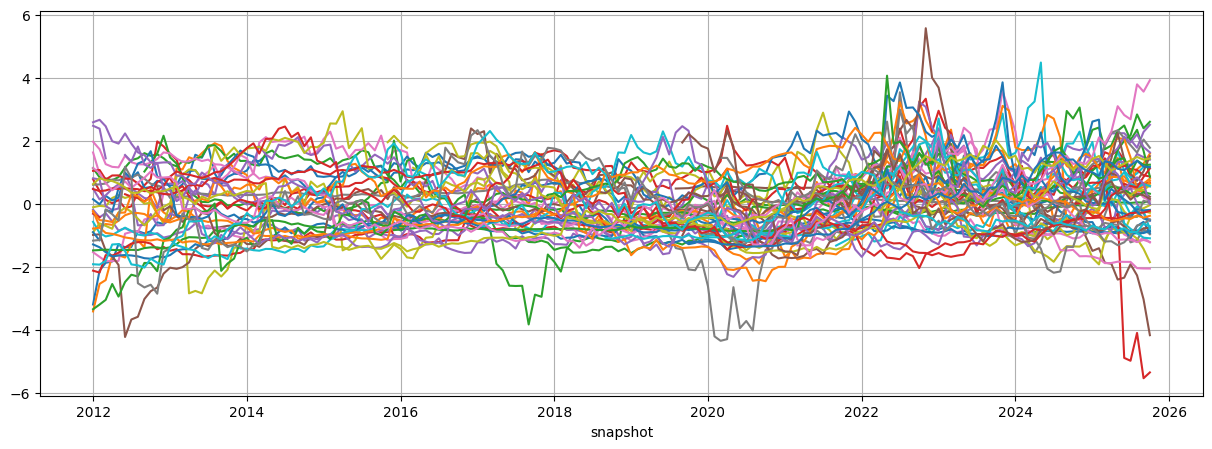

In [20]:
# All undervaluation sequences are scaled, therefore directly comparable
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='undervaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [21]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.